## README

Annotate potential novel peptide/proteins from PacBio long-read RNA seq  
Infer the translation trap/stall mechanism

Input:
- Mapped BAM file after quality control
- Annotated genome gff and FASTA file

Output:
- Excel file: RNA Isoform annotation, Novel ORF annotation
- FASTA file: protein seq

FASTA file will be used in mass spectrometry based proteomics analysis.

## Locate Abnormal Transcripts

Label per isoform against the known gene annotation.

### All isoforms

In [ ]:
# ============================================================
# Isoform clustering + annotation against genes
# Regenerated version:
#   - NO QC filtering here (use your pre-filtered BAM directly)
#   - FIXED coordinate bug for minus-strand isoforms
#   - stores both transcript-oriented 5'/3' and genomic start/end
#
# Input:
#   - high-confidence BAM
#   - genome GFF/GFF3
#
# Output:
#   - isoform_clusters_annotated.tsv
#   - isoform_clusters_annotated.xlsx
#   - optional isoform_membership.tsv
# ============================================================

from __future__ import annotations
import os
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import pysam


# ----------------------------
# Inputs
# ----------------------------
MOTHER_FOLDER = "/data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis"   # change if needed
BAM_PATH = MOTHER_FOLDER + "/syn1.PacBio.FLNC.sorted.HQ.bam"   # change if needed
GFF_PATH = MOTHER_FOLDER + "/syn1_genome/syn1.genes.gff3"                   # change if needed

OUT_FOLDER = MOTHER_FOLDER + "/isoform_annotation"
Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

OUT_ISOFORMS_TSV   = OUT_FOLDER + "/isoform_clusters_annotated.tsv"
OUT_ISOFORMS_XLSX  = OUT_FOLDER + "/isoform_clusters_annotated.xlsx"
OUT_MEMBERSHIP_TSV = OUT_FOLDER + "/isoform_membership.tsv"   # set to None to disable


# ----------------------------
# BAM handling
# ----------------------------
REQUIRE_PRIMARY = True   # keep only primary alignments


# ----------------------------
# Isoform clustering parameters
# ----------------------------
# grouping is by transcript-oriented 5' and 3' ends
BIN5 = 20
BIN3 = 30

MIN_ISOFORM_READS = 2

DO_POST_MERGE = True
MERGE_5P_TOL_BP = 15
MERGE_3P_TOL_BP = 15


# ----------------------------
# Gene / annotation rules
# ----------------------------
GENE_FEATURE_TYPES = {"gene", "CDS"}   # prefer gene, fallback CDS
GENE_ID_KEYS       = ["locus_tag", "ID", "Name", "gene", "gene_id"]
GENE_NAME_KEYS     = ["gene", "Name", "product", "locus_tag", "ID"]

MIN_GENE_OVERLAP_BP = 50
PURE_FRAC = 0.95


# ----------------------------
# Helpers
# ----------------------------
def overlap_len(a0: int, a1: int, b0: int, b1: int) -> int:
    return max(0, min(a1, b1) - max(a0, b0))

def mad(x: np.ndarray) -> float:
    if x.size <= 1:
        return 0.0
    m = np.median(x)
    return float(np.median(np.abs(x - m)))

def bin_pos(pos0: int, binsz: int) -> int:
    return int((pos0 // binsz) * binsz)

def aligned_interval_and_ends(read: pysam.AlignedSegment) -> Optional[Dict[str, int]]:
    """
    Returns a dict with:
      strand  : '+' or '-'
      g_start0: genomic interval start (0-based, inclusive)
      g_end0  : genomic interval end   (0-based, exclusive)
      pos5p0  : transcript-oriented 5' aligned end
      pos3p0  : transcript-oriented 3' aligned end

    Softclips are excluded because pysam reference_start/reference_end
    are aligned coordinates.
    """
    r0 = read.reference_start
    r1 = read.reference_end
    if r0 is None or r1 is None or r1 <= r0:
        return None

    strand = "-" if read.is_reverse else "+"

    if strand == "+":
        pos5p0 = int(r0)
        pos3p0 = int(r1)
    else:
        pos5p0 = int(r1)
        pos3p0 = int(r0)

    return {
        "strand": strand,
        "g_start0": int(r0),
        "g_end0": int(r1),
        "pos5p0": pos5p0,
        "pos3p0": pos3p0,
    }

def parse_gff_attributes(attr_str: str) -> Dict[str, str]:
    d = {}
    if pd.isna(attr_str):
        return d
    for field in str(attr_str).split(";"):
        field = field.strip()
        if not field:
            continue
        if "=" in field:
            k, v = field.split("=", 1)
        elif " " in field:
            k, v = field.split(" ", 1)
            v = v.strip('"')
        else:
            continue
        d[k.strip()] = v.strip()
    return d

def first_attr(attrs: Dict[str, str], keys: List[str], default: str = "") -> str:
    for k in keys:
        if k in attrs and attrs[k] not in ("", ".", None):
            return str(attrs[k])
    return default

def load_genes_from_gff(gff_path: str,
                        feature_types: set[str] = {"gene", "CDS"}) -> pd.DataFrame:
    rows = []
    with open(gff_path, "r") as fh:
        for line in fh:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            chrom, source, feature, start1, end1, score, strand, phase, attrs = parts
            if feature not in feature_types:
                continue
            if strand not in {"+", "-"}:
                continue

            try:
                start1 = int(start1)
                end1   = int(end1)
            except ValueError:
                continue

            if end1 < start1:
                continue

            attrd = parse_gff_attributes(attrs)
            gene_id   = first_attr(attrd, GENE_ID_KEYS, default="")
            gene_name = first_attr(attrd, GENE_NAME_KEYS, default=gene_id)

            rows.append({
                "chrom": chrom,
                "start0": start1 - 1,  # GFF 1-based inclusive -> 0-based half-open
                "end0": end1,
                "strand": strand,
                "gene_id": gene_id if gene_id else f"{feature}:{chrom}:{start1}-{end1}:{strand}",
                "gene_name": gene_name if gene_name else gene_id,
                "feature_type": feature,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No gene/CDS features parsed from GFF.")

    if (df["feature_type"] == "gene").any():
        df = df[df["feature_type"] == "gene"].copy()
    else:
        df = df[df["feature_type"] == "CDS"].copy()

    df = df.sort_values(["chrom", "start0", "end0", "strand"]).reset_index(drop=True)
    return df

def post_merge_isoforms(df: pd.DataFrame,
                        tol5: int = 15,
                        tol3: int = 15) -> pd.DataFrame:
    """
    Merge isoforms within each (chrom, strand) if transcript-oriented
    5' and 3' ends are close.
    """
    if df.empty:
        return df.copy()

    out_rows = []

    for (chrom, strand), g in df.sort_values(
        ["chrom", "strand", "pos5p0", "pos3p0"]
    ).groupby(["chrom", "strand"], sort=False):

        current = None

        for row in g.to_dict("records"):
            if current is None:
                current = row.copy()
                continue

            same_5 = abs(int(row["pos5p0"]) - int(current["pos5p0"])) <= tol5
            same_3 = abs(int(row["pos3p0"]) - int(current["pos3p0"])) <= tol3

            if same_5 and same_3:
                n1 = int(current["n_reads"])
                n2 = int(row["n_reads"])
                n  = n1 + n2

                current["pos5p0"] = int(round((current["pos5p0"] * n1 + row["pos5p0"] * n2) / n))
                current["pos3p0"] = int(round((current["pos3p0"] * n1 + row["pos3p0"] * n2) / n))

                # genomic representative interval should also be updated
                current["start0"] = int(round((current["start0"] * n1 + row["start0"] * n2) / n))
                current["end0"]   = int(round((current["end0"]   * n1 + row["end0"]   * n2) / n))

                current["n_reads"] = n
                current["pos5_list"] += row["pos5_list"]
                current["pos3_list"] += row["pos3_list"]
                current["gstart_list"] += row["gstart_list"]
                current["gend_list"] += row["gend_list"]
                current["read_ids"] += row["read_ids"]
            else:
                out_rows.append(current)
                current = row.copy()

        if current is not None:
            out_rows.append(current)

    out = pd.DataFrame(out_rows)

    # recompute representative values from merged lists for robustness
    out["pos5p0"] = out["pos5_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
    out["pos3p0"] = out["pos3_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
    out["start0"] = out["gstart_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))
    out["end0"]   = out["gend_list"].apply(lambda v: int(np.median(np.array(v, dtype=int))))

    out["start_spread_mad_bp"] = out["pos5_list"].apply(lambda v: mad(np.array(v, dtype=int)))
    out["end_spread_mad_bp"]   = out["pos3_list"].apply(lambda v: mad(np.array(v, dtype=int)))

    return out

def summarize_overlaps_for_isoform(chrom: str,
                                   strand: str,
                                   start0: int,
                                   end0: int,
                                   genes_chr: pd.DataFrame) -> Dict[str, object]:
    """
    Annotate one isoform against genes.
    Here start0/end0 MUST be genomic interval bounds with start0 < end0.
    """
    start0 = int(start0)
    end0   = int(end0)

    if end0 <= start0:
        # return a safe empty annotation instead of raising
        return {
            "isoform_len_bp": 0,
            "sense_overlap_bp": 0,
            "antisense_overlap_bp": 0,
            "intergenic_bp": 0,
            "frac_sense": 0.0,
            "frac_antisense": 0.0,
            "frac_intergenic": 0.0,
            "n_sense_genes": 0,
            "n_antisense_genes": 0,
            "sense_gene_ids": "",
            "sense_gene_names": "",
            "antisense_gene_ids": "",
            "antisense_gene_names": "",
            "class_main": "invalid",
            "class_detail": "invalid_interval",
            "nearest_left_gene_id": "",
            "nearest_left_gene_name": "",
            "nearest_left_dist_bp": np.nan,
            "nearest_right_gene_id": "",
            "nearest_right_gene_name": "",
            "nearest_right_dist_bp": np.nan,
        }

    iso_len = end0 - start0
    cand = genes_chr[(genes_chr["end0"] > start0) & (genes_chr["start0"] < end0)].copy()

    sense_rows = []
    antisense_rows = []
    sense_bp = 0
    antisense_bp = 0

    for _, g in cand.iterrows():
        ol = overlap_len(start0, end0, int(g["start0"]), int(g["end0"]))
        if ol < MIN_GENE_OVERLAP_BP:
            continue

        rec = {
            "gene_id": g["gene_id"],
            "gene_name": g["gene_name"],
            "gene_start0": int(g["start0"]),
            "gene_end0": int(g["end0"]),
            "gene_strand": g["strand"],
            "overlap_bp": int(ol),
            "overlap_frac_isoform": ol / iso_len,
            "overlap_frac_gene": ol / max(1, int(g["end0"]) - int(g["start0"])),
        }

        if g["strand"] == strand:
            sense_rows.append(rec)
            sense_bp += ol
        else:
            antisense_rows.append(rec)
            antisense_bp += ol

    sense_bp = min(sense_bp, iso_len)
    antisense_bp = min(antisense_bp, iso_len)

    # union coverage by any gene to estimate intergenic part
    any_gene_intervals = cand[["start0", "end0"]].sort_values(["start0", "end0"]).to_numpy().tolist()

    merged = []
    for s, e in any_gene_intervals:
        s = max(start0, int(s))
        e = min(end0, int(e))
        if e <= s:
            continue
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)

    covered_any_gene_bp = sum(e - s for s, e in merged)
    intergenic_bp = max(0, iso_len - covered_any_gene_bp)

    frac_sense = sense_bp / iso_len
    frac_antisense = antisense_bp / iso_len
    frac_intergenic = intergenic_bp / iso_len

    if frac_intergenic >= PURE_FRAC:
        class_main = "intergenic"
    elif frac_sense >= PURE_FRAC:
        class_main = "sense"
    elif frac_antisense >= PURE_FRAC:
        class_main = "antisense"
    else:
        class_main = "mixed"

    n_sense = len(sense_rows)
    n_antisense = len(antisense_rows)

    if class_main == "intergenic":
        class_detail = "pure_intergenic"
    elif class_main == "sense":
        class_detail = "sense_single_gene" if n_sense == 1 else "sense_multigene"
    elif class_main == "antisense":
        class_detail = "antisense_single_gene" if n_antisense == 1 else "antisense_multigene"
    else:
        if frac_sense > 0 and frac_intergenic > 0 and frac_antisense == 0:
            class_detail = "mixed_sense_intergenic"
        elif frac_antisense > 0 and frac_intergenic > 0 and frac_sense == 0:
            class_detail = "mixed_antisense_intergenic"
        elif frac_sense > 0 and frac_antisense > 0 and frac_intergenic == 0:
            class_detail = "mixed_sense_antisense"
        else:
            class_detail = "mixed_complex"

    left_genes = genes_chr[genes_chr["end0"] <= start0]
    right_genes = genes_chr[genes_chr["start0"] >= end0]

    nearest_left_gene_id = ""
    nearest_left_gene_name = ""
    nearest_left_dist_bp = np.nan
    if not left_genes.empty:
        lg = left_genes.iloc[left_genes["end0"].argmax()]
        nearest_left_gene_id = lg["gene_id"]
        nearest_left_gene_name = lg["gene_name"]
        nearest_left_dist_bp = int(start0 - lg["end0"])

    nearest_right_gene_id = ""
    nearest_right_gene_name = ""
    nearest_right_dist_bp = np.nan
    if not right_genes.empty:
        rg = right_genes.iloc[right_genes["start0"].argmin()]
        nearest_right_gene_id = rg["gene_id"]
        nearest_right_gene_name = rg["gene_name"]
        nearest_right_dist_bp = int(rg["start0"] - end0)

    return {
        "isoform_len_bp": iso_len,
        "sense_overlap_bp": int(sense_bp),
        "antisense_overlap_bp": int(antisense_bp),
        "intergenic_bp": int(intergenic_bp),
        "frac_sense": float(frac_sense),
        "frac_antisense": float(frac_antisense),
        "frac_intergenic": float(frac_intergenic),
        "n_sense_genes": int(n_sense),
        "n_antisense_genes": int(n_antisense),
        "sense_gene_ids": ",".join([x["gene_id"] for x in sense_rows]),
        "sense_gene_names": ",".join([x["gene_name"] for x in sense_rows]),
        "antisense_gene_ids": ",".join([x["gene_id"] for x in antisense_rows]),
        "antisense_gene_names": ",".join([x["gene_name"] for x in antisense_rows]),
        "class_main": class_main,
        "class_detail": class_detail,
        "nearest_left_gene_id": nearest_left_gene_id,
        "nearest_left_gene_name": nearest_left_gene_name,
        "nearest_left_dist_bp": nearest_left_dist_bp,
        "nearest_right_gene_id": nearest_right_gene_id,
        "nearest_right_gene_name": nearest_right_gene_name,
        "nearest_right_dist_bp": nearest_right_dist_bp,
    }


# ----------------------------
# Load genes
# ----------------------------
genes = load_genes_from_gff(GFF_PATH, feature_types=GENE_FEATURE_TYPES)
print(f"Loaded gene annotations: n={len(genes)}")

genes_by_chrom = {
    chrom: g.reset_index(drop=True)
    for chrom, g in genes.groupby("chrom", sort=False)
}


# ----------------------------
# BAM index if needed
# ----------------------------
if not os.path.exists(BAM_PATH + ".bai"):
    pysam.index(BAM_PATH)

bam = pysam.AlignmentFile(BAM_PATH, "rb")


# ----------------------------
# Pass 1: collect reads into isoform bins
# key = (chrom, strand, 5'bin, 3'bin)
# ----------------------------
isoform_groups: Dict[Tuple[str, str, int, int], Dict[str, object]] = {}

for chrom in bam.references:
    try:
        iterator = bam.fetch(chrom)
    except ValueError:
        continue

    for read in iterator:
        if read.is_unmapped:
            continue
        if REQUIRE_PRIMARY and (read.is_secondary or read.is_supplementary):
            continue

        info = aligned_interval_and_ends(read)
        if info is None:
            continue

        strand = info["strand"]
        g_start0 = info["g_start0"]
        g_end0   = info["g_end0"]
        pos5p0   = info["pos5p0"]
        pos3p0   = info["pos3p0"]

        sk = bin_pos(pos5p0, BIN5)
        ek = bin_pos(pos3p0, BIN3)

        key = (chrom, strand, sk, ek)
        if key not in isoform_groups:
            isoform_groups[key] = {
                "chrom": chrom,
                "strand": strand,
                "start_key": sk,
                "end_key": ek,
                "pos5_list": [],
                "pos3_list": [],
                "gstart_list": [],
                "gend_list": [],
                "read_ids": [],
            }

        isoform_groups[key]["pos5_list"].append(int(pos5p0))
        isoform_groups[key]["pos3_list"].append(int(pos3p0))
        isoform_groups[key]["gstart_list"].append(int(g_start0))
        isoform_groups[key]["gend_list"].append(int(g_end0))
        isoform_groups[key]["read_ids"].append(read.query_name)

bam.close()


# ----------------------------
# Convert raw bins to DataFrame
# ----------------------------
rows = []
for (chrom, strand, sk, ek), d in isoform_groups.items():
    n = len(d["read_ids"])
    if n < MIN_ISOFORM_READS:
        continue

    pos5 = np.array(d["pos5_list"], dtype=int)
    pos3 = np.array(d["pos3_list"], dtype=int)
    gs   = np.array(d["gstart_list"], dtype=int)
    ge   = np.array(d["gend_list"], dtype=int)

    rep_pos5p0 = int(np.median(pos5))
    rep_pos3p0 = int(np.median(pos3))
    rep_start0 = int(np.median(gs))
    rep_end0   = int(np.median(ge))

    # safety
    if rep_end0 <= rep_start0:
        continue

    rows.append({
        "chrom": chrom,
        "strand": strand,
        "start_key": sk,
        "end_key": ek,
        "pos5p0": rep_pos5p0,
        "pos3p0": rep_pos3p0,
        "start0": rep_start0,
        "end0": rep_end0,
        "n_reads": n,
        "pos5_list": d["pos5_list"],
        "pos3_list": d["pos3_list"],
        "gstart_list": d["gstart_list"],
        "gend_list": d["gend_list"],
        "read_ids": d["read_ids"],
        "start_spread_mad_bp": mad(pos5),
        "end_spread_mad_bp": mad(pos3),
    })

clusters = pd.DataFrame(rows)
if clusters.empty:
    raise ValueError("No isoforms produced. Check BAM path or clustering thresholds.")

print(f"Raw isoform bins: n={len(clusters)}")


# ----------------------------
# Optional post-merge
# ----------------------------
if DO_POST_MERGE:
    clusters = post_merge_isoforms(clusters, tol5=MERGE_5P_TOL_BP, tol3=MERGE_3P_TOL_BP)
    print(f"After post-merge: n={len(clusters)}")

clusters = clusters.copy().reset_index(drop=True)
clusters["isoform_id"] = [f"ISO_{i+1:06d}" for i in range(len(clusters))]


# ----------------------------
# Annotate isoforms against genes
# ----------------------------
annot_rows = []

for _, r in clusters.iterrows():
    chrom = r["chrom"]
    strand = r["strand"]
    start0 = int(r["start0"])
    end0   = int(r["end0"])

    if end0 <= start0:
        ann = {
            "isoform_len_bp": 0,
            "sense_overlap_bp": 0,
            "antisense_overlap_bp": 0,
            "intergenic_bp": 0,
            "frac_sense": 0.0,
            "frac_antisense": 0.0,
            "frac_intergenic": 0.0,
            "n_sense_genes": 0,
            "n_antisense_genes": 0,
            "sense_gene_ids": "",
            "sense_gene_names": "",
            "antisense_gene_ids": "",
            "antisense_gene_names": "",
            "class_main": "invalid",
            "class_detail": "invalid_interval",
            "nearest_left_gene_id": "",
            "nearest_left_gene_name": "",
            "nearest_left_dist_bp": np.nan,
            "nearest_right_gene_id": "",
            "nearest_right_gene_name": "",
            "nearest_right_dist_bp": np.nan,
        }
    elif chrom not in genes_by_chrom:
        ann = {
            "isoform_len_bp": end0 - start0,
            "sense_overlap_bp": 0,
            "antisense_overlap_bp": 0,
            "intergenic_bp": end0 - start0,
            "frac_sense": 0.0,
            "frac_antisense": 0.0,
            "frac_intergenic": 1.0,
            "n_sense_genes": 0,
            "n_antisense_genes": 0,
            "sense_gene_ids": "",
            "sense_gene_names": "",
            "antisense_gene_ids": "",
            "antisense_gene_names": "",
            "class_main": "intergenic",
            "class_detail": "pure_intergenic",
            "nearest_left_gene_id": "",
            "nearest_left_gene_name": "",
            "nearest_left_dist_bp": np.nan,
            "nearest_right_gene_id": "",
            "nearest_right_gene_name": "",
            "nearest_right_dist_bp": np.nan,
        }
    else:
        ann = summarize_overlaps_for_isoform(
            chrom=chrom,
            strand=strand,
            start0=start0,
            end0=end0,
            genes_chr=genes_by_chrom[chrom]
        )

    rec = {
        "isoform_id": r["isoform_id"],
        "chrom": chrom,
        "strand": strand,

        # genomic interval
        "start0": start0,
        "end0": end0,

        # transcript-oriented ends
        "pos5p0": int(r["pos5p0"]),
        "pos3p0": int(r["pos3p0"]),

        "n_reads": int(r["n_reads"]),
        "start_spread_mad_bp": float(r["start_spread_mad_bp"]),
        "end_spread_mad_bp": float(r["end_spread_mad_bp"]),
        "start_key": int(r["start_key"]),
        "end_key": int(r["end_key"]),
    }
    rec.update(ann)
    annot_rows.append(rec)

isoforms_annot = pd.DataFrame(annot_rows)

isoforms_annot = isoforms_annot.sort_values(
    ["chrom", "start0", "end0", "strand", "n_reads"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\nIsoform class counts:")
print(isoforms_annot["class_main"].value_counts(dropna=False))


# ----------------------------
# Optional membership table
# ----------------------------
if OUT_MEMBERSHIP_TSV is not None:
    mem_rows = []
    for _, r in clusters.iterrows():
        isoform_id = r["isoform_id"]
        chrom = r["chrom"]
        strand = r["strand"]
        for rid, p5, p3, gs, ge in zip(
            r["read_ids"], r["pos5_list"], r["pos3_list"], r["gstart_list"], r["gend_list"]
        ):
            mem_rows.append({
                "isoform_id": isoform_id,
                "chrom": chrom,
                "strand": strand,
                "read_id": rid,
                "pos5p0": int(p5),
                "pos3p0": int(p3),
                "start0": int(gs),
                "end0": int(ge),
            })
    membership = pd.DataFrame(mem_rows)
    membership.to_csv(OUT_MEMBERSHIP_TSV, sep="\t", index=False)
    print(f"\n✅ wrote {OUT_MEMBERSHIP_TSV} | n_rows={len(membership)}")


# ----------------------------
# Write outputs
# ----------------------------
isoforms_annot.to_csv(OUT_ISOFORMS_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_ISOFORMS_XLSX, engine="openpyxl") as writer:
    isoforms_annot.to_excel(writer, sheet_name="isoforms", index=False)

    class_summary = (
        isoforms_annot["class_main"]
        .value_counts(dropna=False)
        .rename_axis("class_main")
        .reset_index(name="n_isoforms")
    )
    class_summary.to_excel(writer, sheet_name="class_summary", index=False)

    detail_summary = (
        isoforms_annot["class_detail"]
        .value_counts(dropna=False)
        .rename_axis("class_detail")
        .reset_index(name="n_isoforms")
    )
    detail_summary.to_excel(writer, sheet_name="detail_summary", index=False)

print(f"\n✅ wrote {OUT_ISOFORMS_TSV}")
print(f"✅ wrote {OUT_ISOFORMS_XLSX}")

display(isoforms_annot.head(20))

Loaded gene annotations: n=911
Raw isoform bins: n=89638
After post-merge: n=82806

Isoform class counts:
class_main
sense         60499
mixed         21452
antisense       829
intergenic       26
Name: count, dtype: int64

✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/isoform_annotation/isoform_membership.tsv | n_rows=2470304

✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/isoform_annotation/isoform_clusters_annotated.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/isoform_annotation/isoform_clusters_annotated.xlsx


,isoform_id,chrom,strand,start0,end0,pos5p0,pos3p0,n_reads,start_spread_mad_bp,end_spread_mad_bp,...,antisense_gene_ids,antisense_gene_names,class_main,class_detail,nearest_left_gene_id,nearest_left_gene_name,nearest_left_dist_bp,nearest_right_gene_id,nearest_right_gene_name,nearest_right_dist_bp
0,ISO_000001,CP002027.1,+,0,572,0,572,5,0.0,1.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,938.0
1,ISO_000002,CP002027.1,+,0,616,0,616,2,0.0,11.5,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,894.0
2,ISO_000003,CP002027.1,+,0,659,0,659,24,0.0,3.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,851.0
3,ISO_000004,CP002027.1,+,0,709,0,709,8,0.0,0.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,801.0
4,ISO_000005,CP002027.1,+,0,725,0,725,2,0.0,0.5,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,785.0
5,ISO_000006,CP002027.1,+,0,818,0,818,11,0.0,1.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,692.0
6,ISO_000007,CP002027.1,+,0,852,0,852,5250,0.0,1.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,658.0
7,ISO_000008,CP002027.1,+,0,872,0,872,8,0.0,1.5,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,638.0
8,ISO_000009,CP002027.1,+,0,904,0,904,6,0.0,2.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,606.0
9,ISO_000010,CP002027.1,+,0,939,0,939,4,0.0,3.0,...,,,sense,sense_single_gene,,,NaN,MMSYN1_0002,dnaN,571.0


### Filter out abnormal isoforms

In [ ]:
import numpy as np
import pandas as pd

df = isoforms_annot.copy()

# -----------------------------------
# Derived metrics
# -----------------------------------
df["abnormal_frac"] = df["frac_antisense"] + df["frac_intergenic"]
df["genic_frac"] = df["frac_sense"] + df["frac_antisense"]

# safer length/read summaries if not already numeric
for c in ["n_reads", "isoform_len_bp", "start_spread_mad_bp", "end_spread_mad_bp",
          "frac_sense", "frac_antisense", "frac_intergenic", "abnormal_frac"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------------
# 1) Main class counts
# -----------------------------------
main_counts = (
    df["class_main"]
    .value_counts(dropna=False)
    .rename_axis("class_main")
    .reset_index(name="n_isoforms")
)

display(main_counts)

# -----------------------------------
# 2) Mixed subclass counts
# -----------------------------------
mixed = df[df["class_main"] == "mixed"].copy()

mixed_counts = (
    mixed["class_detail"]
    .value_counts(dropna=False)
    .rename_axis("class_detail")
    .reset_index(name="n_isoforms")
)

display(mixed_counts)

# -----------------------------------
# 3) Support-weighted summary by class_detail
# -----------------------------------
summary_by_detail = (
    df.groupby(["class_main", "class_detail"], dropna=False)
      .agg(
          n_isoforms=("isoform_id", "size"),
          total_reads=("n_reads", "sum"),
          median_reads=("n_reads", "median"),
          mean_reads=("n_reads", "mean"),
          median_len_bp=("isoform_len_bp", "median"),
          mean_len_bp=("isoform_len_bp", "mean"),
          median_frac_sense=("frac_sense", "median"),
          median_frac_antisense=("frac_antisense", "median"),
          median_frac_intergenic=("frac_intergenic", "median"),
          median_abnormal_frac=("abnormal_frac", "median"),
          median_start_mad=("start_spread_mad_bp", "median"),
          median_end_mad=("end_spread_mad_bp", "median"),
      )
      .reset_index()
      .sort_values(["class_main", "total_reads"], ascending=[True, False])
)

display(summary_by_detail)

# -----------------------------------
# 4) Mixed-only quantitative summary
# -----------------------------------
mixed_summary = (
    mixed.groupby("class_detail", dropna=False)
         .agg(
             n_isoforms=("isoform_id", "size"),
             total_reads=("n_reads", "sum"),
             median_reads=("n_reads", "median"),
             q75_reads=("n_reads", lambda x: np.quantile(x, 0.75)),
             median_len_bp=("isoform_len_bp", "median"),
             median_frac_sense=("frac_sense", "median"),
             median_frac_antisense=("frac_antisense", "median"),
             median_frac_intergenic=("frac_intergenic", "median"),
             median_abnormal_frac=("abnormal_frac", "median"),
             median_start_mad=("start_spread_mad_bp", "median"),
             median_end_mad=("end_spread_mad_bp", "median"),
         )
         .reset_index()
         .sort_values("total_reads", ascending=False)
)

display(mixed_summary)

,class_main,n_isoforms
0,sense,60499
1,mixed,21452
2,antisense,829
3,intergenic,26


,class_detail,n_isoforms
0,mixed_sense_intergenic,18597
1,mixed_complex,2162
2,mixed_antisense_intergenic,644
3,mixed_sense_antisense,49


,class_main,class_detail,n_isoforms,total_reads,median_reads,mean_reads,median_len_bp,mean_len_bp,median_frac_sense,median_frac_antisense,median_frac_intergenic,median_abnormal_frac,median_start_mad,median_end_mad
0,antisense,antisense_multigene,511,2049,2.0,4.009785,1782.0,1868.933464,0.000000,0.993598,0.007420,1.000000,0.0,1.00
1,antisense,antisense_single_gene,318,1541,2.0,4.845912,1337.0,1402.044025,0.000000,1.000000,0.000000,1.000000,0.0,1.25
2,intergenic,pure_intergenic,26,1235,6.0,47.500000,595.5,641.269231,0.000000,0.000000,1.000000,1.000000,0.0,1.00
6,mixed,mixed_sense_intergenic,18597,927137,4.0,49.854116,1527.0,1683.012583,0.914859,0.000000,0.083538,0.083538,0.5,1.00
3,mixed,mixed_antisense_intergenic,644,35319,3.0,54.843168,1511.5,1654.936335,0.000000,0.874534,0.124155,1.000000,0.0,1.00
4,mixed,mixed_complex,2162,19570,3.0,9.051804,1878.0,2031.677151,0.599780,0.304431,0.069247,0.405803,0.0,1.00
5,mixed,mixed_sense_antisense,49,333,4.0,6.795918,1432.0,1466.244898,0.794059,0.248469,0.000000,0.248469,0.0,1.50
7,sense,sense_multigene,36850,816672,4.0,22.162062,1965.0,2125.456662,0.987612,0.000000,0.012470,0.012473,1.5,1.00
8,sense,sense_single_gene,23649,666448,4.0,28.180811,1286.0,1388.176075,1.000000,0.000000,0.000000,0.000000,1.5,1.00


,class_detail,n_isoforms,total_reads,median_reads,q75_reads,median_len_bp,median_frac_sense,median_frac_antisense,median_frac_intergenic,median_abnormal_frac,median_start_mad,median_end_mad
3,mixed_sense_intergenic,18597,927137,4.0,11.0,1527.0,0.914859,0.000000,0.083538,0.083538,0.5,1.0
0,mixed_antisense_intergenic,644,35319,3.0,6.0,1511.5,0.000000,0.874534,0.124155,1.000000,0.0,1.0
1,mixed_complex,2162,19570,3.0,5.0,1878.0,0.599780,0.304431,0.069247,0.405803,0.0,1.0
2,mixed_sense_antisense,49,333,4.0,7.0,1432.0,0.794059,0.248469,0.000000,0.248469,0.0,1.5


In [9]:
OUT_FILTERED_XLSX = OUT_FOLDER + "/isoform_abnormal_filtered.xlsx"

df = isoforms_annot.copy()
df["abnormal_frac"] = df["frac_antisense"] + df["frac_intergenic"]
df["abnormal_bp"] = df["antisense_overlap_bp"] + df["intergenic_bp"]

core_abnormal = df[
    (df["class_main"].isin(["intergenic", "antisense"])) |
    (df["class_detail"].isin(["mixed_sense_intergenic", "mixed_antisense_intergenic"]))
].copy()

print("core_abnormal:", len(core_abnormal))
display(core_abnormal["class_detail"].value_counts(dropna=False))

core_abnormal_strict = core_abnormal[
    (core_abnormal["n_reads"] >= 10) &
    (core_abnormal["abnormal_frac"] >= 0.20) &
    (core_abnormal["abnormal_bp"] >= 30)
].copy()

print("core_abnormal_strict:", len(core_abnormal_strict))
display(core_abnormal_strict["class_detail"].value_counts(dropna=False))

exploratory_mixed = df[
    (df["class_main"] == "mixed") &
    (df["class_detail"].isin(["mixed_sense_antisense", "mixed_complex"])) &
    (df["n_reads"] >= 10) &
    (df["abnormal_frac"] >= 0.30) &
    (df["abnormal_bp"] >= 60)
].copy()

print("exploratory_mixed:", len(exploratory_mixed))
display(exploratory_mixed["class_detail"].value_counts(dropna=False))

orf_input = pd.concat(
    [core_abnormal_strict, exploratory_mixed],
    ignore_index=True
).drop_duplicates(subset=["isoform_id"])

print("Final ORF-input isoforms:", len(orf_input))
display(orf_input["class_detail"].value_counts(dropna=False))

with pd.ExcelWriter(OUT_FILTERED_XLSX, engine="openpyxl") as writer:
    # df.to_excel(writer, sheet_name="all_isoforms", index=False)
    # core_abnormal.to_excel(writer, sheet_name="core_abnormal_raw", index=False)
    core_abnormal_strict.to_excel(writer, sheet_name="core_abnormal_strict", index=False)
    exploratory_mixed.to_excel(writer, sheet_name="exploratory_mixed", index=False)
    orf_input.to_excel(writer, sheet_name="orf_input", index=False)
    mixed_summary.to_excel(writer, sheet_name="mixed_summary", index=False)
    summary_by_detail.to_excel(writer, sheet_name="detail_summary", index=False)

print("Wrote:", OUT_FILTERED_XLSX)
print("ORF-input isoforms:", len(orf_input))

core_abnormal: 20096


class_detail
mixed_sense_intergenic        18597
mixed_antisense_intergenic      644
antisense_multigene             511
antisense_single_gene           318
pure_intergenic                  26
Name: count, dtype: int64

core_abnormal_strict: 686


class_detail
mixed_sense_intergenic        536
mixed_antisense_intergenic     92
antisense_multigene            26
antisense_single_gene          22
pure_intergenic                10
Name: count, dtype: int64

exploratory_mixed: 130


class_detail
mixed_complex            129
mixed_sense_antisense      1
Name: count, dtype: int64

Final ORF-input isoforms: 816


class_detail
mixed_sense_intergenic        536
mixed_complex                 129
mixed_antisense_intergenic     92
antisense_multigene            26
antisense_single_gene          22
pure_intergenic                10
mixed_sense_antisense           1
Name: count, dtype: int64

Wrote: /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/isoform_annotation/isoform_abnormal_filtered.xlsx
ORF-input isoforms: 816


In [21]:
orf_copy = orf_input.copy()

orf_ranked = orf_copy.sort_values(
    ["n_reads", "abnormal_bp", "abnormal_frac"],
    ascending=[False, False, False]
)

print("Top ORF-input isoforms:")
columns = ["strand", "start0", "end0", "n_reads", "isoform_len_bp", "frac_sense", 
"frac_antisense", "frac_intergenic", "abnormal_frac", "abnormal_bp", "class_detail", 'sense_gene_ids', 'antisense_gene_ids']

class_details = ["mixed_complex", "mixed_sense_antisense", "mixed_antisense_intergenic"]

display(orf_ranked[orf_ranked["class_detail"].isin(class_details)].head(20)[columns])

Top ORF-input isoforms:


,strand,start0,end0,n_reads,isoform_len_bp,frac_sense,frac_antisense,frac_intergenic,abnormal_frac,abnormal_bp,class_detail,sense_gene_ids,antisense_gene_ids
11,+,27522,28407,15477,885,0.000000,0.749153,0.242938,0.992090,878,mixed_antisense_intergenic,,MMSYN1_0918
12,+,27522,28435,7785,913,0.000000,0.726177,0.266156,0.992333,906,mixed_antisense_intergenic,,MMSYN1_0918
16,+,27522,28630,7537,1108,0.000000,0.598375,0.395307,0.993682,1101,mixed_antisense_intergenic,,MMSYN1_0918
785,-,812150,813731,517,1581,0.192283,0.576850,0.230867,0.807717,1277,mixed_complex,"MMSYN1_0678,MMSYN1_0679,MMSYN1_0680,MMSYN1_0681",MMSYN1_0677
783,-,812150,813533,406,1383,0.109906,0.659436,0.230658,0.890094,1231,mixed_complex,"MMSYN1_0678,MMSYN1_0679",MMSYN1_0677
765,+,441031,442934,337,1903,0.657383,0.267998,0.094587,0.362585,690,mixed_complex,"MMSYN1_0349,MMSYN1_0350,MMSYN1_0352,MMSYN1_0353",MMSYN1_0351
713,+,67152,68661,278,1509,0.560636,0.376408,0.074221,0.450630,680,mixed_complex,MMSYN1_0041,MMSYN1_0040
7,+,27121,28406,260,1285,0.000000,0.833463,0.166537,1.000000,1285,mixed_antisense_intergenic,,"MMSYN1_0917,MMSYN1_0918"
751,+,389566,391154,244,1588,0.318640,0.450882,0.230479,0.681360,1082,mixed_complex,"MMSYN1_0307,MMSYN1_0308",MMSYN1_0306
747,+,375240,376291,223,1051,0.254044,0.489058,0.256898,0.745956,784,mixed_complex,MMSYN1_0294,MMSYN1_0293


## Predict Novel ORFs

In [22]:
# ============================================================
# Cell 1
# Extract transcript sequences from abnormal isoforms
# Enumerate raw candidate ORFs using:
#   - translation table 4
#   - ATG-only starts
#   - stop codons: TAA, TAG
#   - keep complete ORFs and no-stop ORFs
# ============================================================

from __future__ import annotations
import os
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import pysam


# ----------------------------
# Inputs
# ----------------------------
FASTA_PATH = MOTHER_FOLDER + "/syn1_genome/syn1_genome.fasta"            # <-- change if needed
GFF_PATH   = MOTHER_FOLDER + "/syn1_genome/syn1.genes.gff3"  # <-- change if needed

OUT_FOLDER = MOTHER_FOLDER + "/novel_orf_discovery"
Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

OUT_RAW_ORFS_TSV  = OUT_FOLDER + "/candidate_orfs_raw.tsv"
OUT_RAW_ORFS_XLSX = OUT_FOLDER + "/candidate_orfs_raw.xlsx"


# ----------------------------
# Required input dataframe
# ----------------------------
# Expect: orf_input
# Columns needed:
#   isoform_id, chrom, strand, start0, end0, n_reads,
#   class_main, class_detail,
#   frac_sense, frac_antisense, frac_intergenic,
#   sense_overlap_bp, antisense_overlap_bp, intergenic_bp
#
# If your dataframe has extra columns, that is fine.
# ----------------------------
required_iso_cols = [
    "isoform_id", "chrom", "strand", "start0", "end0", "n_reads",
    "class_main", "class_detail",
    "frac_sense", "frac_antisense", "frac_intergenic",
    "sense_overlap_bp", "antisense_overlap_bp", "intergenic_bp"
]
missing = [c for c in required_iso_cols if c not in orf_input.columns]
if missing:
    raise ValueError(f"orf_input is missing required columns: {missing}")


# ----------------------------
# Genetic code: Translation table 4
# Mycoplasma/Spiroplasma
# TGA = W ; stops = TAA, TAG
# ----------------------------
START_CODONS = {"ATG"}
STOP_CODONS  = {"TAA", "TAG"}

GENETIC_CODE_4 = {
    "TTT":"F","TTC":"F","TTA":"L","TTG":"L",
    "TCT":"S","TCC":"S","TCA":"S","TCG":"S",
    "TAT":"Y","TAC":"Y","TAA":"*","TAG":"*",
    "TGT":"C","TGC":"C","TGA":"W","TGG":"W",

    "CTT":"L","CTC":"L","CTA":"L","CTG":"L",
    "CCT":"P","CCC":"P","CCA":"P","CCG":"P",
    "CAT":"H","CAC":"H","CAA":"Q","CAG":"Q",
    "CGT":"R","CGC":"R","CGA":"R","CGG":"R",

    "ATT":"I","ATC":"I","ATA":"I","ATG":"M",
    "ACT":"T","ACC":"T","ACA":"T","ACG":"T",
    "AAT":"N","AAC":"N","AAA":"K","AAG":"K",
    "AGT":"S","AGC":"S","AGA":"R","AGG":"R",

    "GTT":"V","GTC":"V","GTA":"V","GTG":"V",
    "GCT":"A","GCC":"A","GCA":"A","GCG":"A",
    "GAT":"D","GAC":"D","GAA":"E","GAG":"E",
    "GGT":"G","GGC":"G","GGA":"G","GGG":"G",
}


# ----------------------------
# ORF thresholds
# ----------------------------
MIN_AA_LEN_MAIN  = 24
MIN_AA_LEN_MICRO = 15


# ----------------------------
# Helpers
# ----------------------------
def revcomp(seq: str) -> str:
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return seq.translate(comp)[::-1]

def translate_code4(nt_seq: str, require_full_codons: bool = True) -> str:
    """
    Translate using code 4.
    Assumes the ORF sequence starts at the start codon.
    For complete ORFs, include the terminal stop codon in nt_seq and translation will contain '*'.
    For no-stop ORFs, translation stops at the last full codon available.
    """
    seq = nt_seq.upper()
    if require_full_codons:
        usable = (len(seq) // 3) * 3
        seq = seq[:usable]

    aa = []
    for i in range(0, len(seq), 3):
        codon = seq[i:i+3]
        if len(codon) < 3:
            break
        aa.append(GENETIC_CODE_4.get(codon, "X"))
    return "".join(aa)

def load_genes_from_gff_if_needed(gff_path: str) -> pd.DataFrame:
    if "genes" in globals() and isinstance(globals()["genes"], pd.DataFrame):
        g = globals()["genes"].copy()
        required = {"chrom","start0","end0","strand","gene_id","gene_name"}
        if required.issubset(set(g.columns)):
            return g

    def parse_gff_attributes(attr_str: str) -> Dict[str, str]:
        d = {}
        if pd.isna(attr_str):
            return d
        for field in str(attr_str).split(";"):
            field = field.strip()
            if not field:
                continue
            if "=" in field:
                k, v = field.split("=", 1)
            elif " " in field:
                k, v = field.split(" ", 1)
                v = v.strip('"')
            else:
                continue
            d[k.strip()] = v.strip()
        return d

    def first_attr(attrs: Dict[str, str], keys: List[str], default: str = "") -> str:
        for k in keys:
            if k in attrs and attrs[k] not in ("", ".", None):
                return str(attrs[k])
        return default

    GENE_FEATURE_TYPES = {"gene", "CDS"}
    GENE_ID_KEYS       = ["locus_tag", "ID", "Name", "gene", "gene_id"]
    GENE_NAME_KEYS     = ["gene", "Name", "product", "locus_tag", "ID"]

    rows = []
    with open(gff_path, "r") as fh:
        for line in fh:
            if not line.strip() or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 9:
                continue
            chrom, source, feature, start1, end1, score, strand, phase, attrs = parts
            if feature not in GENE_FEATURE_TYPES:
                continue
            if strand not in {"+", "-"}:
                continue
            try:
                start1 = int(start1)
                end1   = int(end1)
            except ValueError:
                continue

            attrd = parse_gff_attributes(attrs)
            gene_id   = first_attr(attrd, GENE_ID_KEYS, default="")
            gene_name = first_attr(attrd, GENE_NAME_KEYS, default=gene_id)

            rows.append({
                "chrom": chrom,
                "start0": start1 - 1,
                "end0": end1,
                "strand": strand,
                "gene_id": gene_id if gene_id else f"{feature}:{chrom}:{start1}-{end1}:{strand}",
                "gene_name": gene_name if gene_name else gene_id,
                "feature_type": feature,
            })

    g = pd.DataFrame(rows)
    if g.empty:
        raise ValueError("No gene/CDS features parsed from GFF.")

    if (g["feature_type"] == "gene").any():
        g = g[g["feature_type"] == "gene"].copy()
    else:
        g = g[g["feature_type"] == "CDS"].copy()

    g = g.sort_values(["chrom","start0","end0","strand"]).reset_index(drop=True)
    return g

def fetch_isoform_sequence(fasta: pysam.FastaFile, chrom: str, start0: int, end0: int, strand: str) -> str:
    seq = fasta.fetch(chrom, start0, end0).upper()
    if strand == "-":
        seq = revcomp(seq)
    return seq

def tx_local_to_genomic(iso_start0: int, iso_end0: int, strand: str, local_start0: int, local_end0: int) -> Tuple[int, int]:
    """
    Map transcript-local half-open interval [local_start0, local_end0) to genomic half-open interval.
    """
    if strand == "+":
        g0 = iso_start0 + local_start0
        g1 = iso_start0 + local_end0
    else:
        g0 = iso_end0 - local_end0
        g1 = iso_end0 - local_start0
    return int(g0), int(g1)

def enumerate_orfs_one_isoform(tx_seq: str,
                               min_aa_len_micro: int = 15,
                               start_codons: set[str] = {"ATG"},
                               stop_codons: set[str] = {"TAA", "TAG"}) -> List[Dict[str, object]]:
    """
    Enumerate ORFs on one transcript sequence (already oriented 5'->3').
    Returns both complete ORFs and no-stop ORFs.
    local_start0/local_end0 are transcript-local half-open coordinates.
    """
    seq = tx_seq.upper()
    n = len(seq)
    rows = []

    for i in range(0, n - 2):
        codon = seq[i:i+3]
        if codon not in start_codons:
            continue

        found_stop = False
        stop_j = None

        # scan in frame
        j = i + 3
        while j + 3 <= n:
            cod = seq[j:j+3]
            if cod in stop_codons:
                found_stop = True
                stop_j = j
                break
            j += 3

        if found_stop:
            nt_seq = seq[i:stop_j+3]
            aa_seq = translate_code4(nt_seq, require_full_codons=True)
            # aa_seq includes trailing '*'
            aa_len_no_stop = len(aa_seq.rstrip("*"))
            if aa_len_no_stop >= min_aa_len_micro:
                rows.append({
                    "orf_local_start0": i,
                    "orf_local_end0": stop_j + 3,
                    "start_codon": "ATG",
                    "stop_codon": seq[stop_j:stop_j+3],
                    "termination_status": "complete_stop",
                    "orf_nt_seq": nt_seq,
                    "orf_aa_seq": aa_seq.rstrip("*"),
                    "orf_aa_seq_with_stop": aa_seq,
                    "aa_len": aa_len_no_stop,
                    "nt_len": len(nt_seq),
                })
        else:
            # no in-frame stop within transcript
            usable_end = i + ((n - i) // 3) * 3
            if usable_end - i < 3:
                continue
            nt_seq = seq[i:usable_end]
            aa_seq = translate_code4(nt_seq, require_full_codons=True)
            aa_len = len(aa_seq)
            if aa_len >= min_aa_len_micro:
                rows.append({
                    "orf_local_start0": i,
                    "orf_local_end0": usable_end,
                    "start_codon": "ATG",
                    "stop_codon": "",
                    "termination_status": "no_stop_within_isoform",
                    "orf_nt_seq": nt_seq,
                    "orf_aa_seq": aa_seq,
                    "orf_aa_seq_with_stop": aa_seq,
                    "aa_len": aa_len,
                    "nt_len": len(nt_seq),
                })

    return rows


# ----------------------------
# Load genes and FASTA
# ----------------------------
genes = load_genes_from_gff_if_needed(GFF_PATH)
genes_by_chrom = {
    chrom: g.reset_index(drop=True)
    for chrom, g in genes.groupby("chrom", sort=False)
}

fasta = pysam.FastaFile(FASTA_PATH)


# ----------------------------
# Enumerate ORFs
# ----------------------------
raw_rows = []

for _, iso in orf_input.iterrows():
    isoform_id = iso["isoform_id"]
    chrom      = str(iso["chrom"])
    strand     = str(iso["strand"])
    start0     = int(iso["start0"])
    end0       = int(iso["end0"])

    tx_seq = fetch_isoform_sequence(fasta, chrom, start0, end0, strand)
    tx_len = len(tx_seq)
    if tx_len < 3:
        continue

    iso_orfs = enumerate_orfs_one_isoform(
        tx_seq=tx_seq,
        min_aa_len_micro=MIN_AA_LEN_MICRO,
        start_codons=START_CODONS,
        stop_codons=STOP_CODONS,
    )

    for k, orf in enumerate(iso_orfs, start=1):
        g0, g1 = tx_local_to_genomic(
            iso_start0=start0,
            iso_end0=end0,
            strand=strand,
            local_start0=int(orf["orf_local_start0"]),
            local_end0=int(orf["orf_local_end0"]),
        )

        aa_len = int(orf["aa_len"])
        if aa_len >= MIN_AA_LEN_MAIN:
            length_tier = "main"
        else:
            length_tier = "micro"

        raw_rows.append({
            "orf_id": f"{isoform_id}__ORF_{k:03d}",
            "isoform_id": isoform_id,
            "chrom": chrom,
            "strand": strand,

            "isoform_start0": start0,
            "isoform_end0": end0,
            "isoform_len_bp": end0 - start0,
            "isoform_n_reads": int(iso["n_reads"]),
            "class_main": iso["class_main"],
            "class_detail": iso["class_detail"],

            "isoform_frac_sense": float(iso["frac_sense"]),
            "isoform_frac_antisense": float(iso["frac_antisense"]),
            "isoform_frac_intergenic": float(iso["frac_intergenic"]),
            "isoform_sense_overlap_bp": int(iso["sense_overlap_bp"]),
            "isoform_antisense_overlap_bp": int(iso["antisense_overlap_bp"]),
            "isoform_intergenic_bp": int(iso["intergenic_bp"]),

            "tx_seq": tx_seq,
            "tx_len_bp": tx_len,

            "orf_local_start0": int(orf["orf_local_start0"]),
            "orf_local_end0": int(orf["orf_local_end0"]),
            "orf_genomic_start0": int(g0),
            "orf_genomic_end0": int(g1),

            "start_codon": orf["start_codon"],
            "stop_codon": orf["stop_codon"],
            "termination_status": orf["termination_status"],

            "orf_nt_len": int(orf["nt_len"]),
            "orf_aa_len": int(orf["aa_len"]),
            "length_tier": length_tier,

            "orf_nt_seq": orf["orf_nt_seq"],
            "orf_aa_seq": orf["orf_aa_seq"],
            "orf_aa_seq_with_stop": orf["orf_aa_seq_with_stop"],
        })

fasta.close()

raw_orfs = pd.DataFrame(raw_rows)

if raw_orfs.empty:
    raise ValueError("No candidate ORFs found. Check FASTA path, coordinates, or thresholds.")

raw_orfs = raw_orfs.sort_values(
    ["chrom","isoform_start0","isoform_end0","orf_local_start0","orf_local_end0"]
).reset_index(drop=True)

print(f"Candidate raw ORFs: n={len(raw_orfs)}")
print(raw_orfs["termination_status"].value_counts(dropna=False))
print(raw_orfs["length_tier"].value_counts(dropna=False))

raw_orfs.to_csv(OUT_RAW_ORFS_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_RAW_ORFS_XLSX, engine="openpyxl") as writer:
    raw_orfs.to_excel(writer, sheet_name="raw_orfs", index=False)
    raw_orfs["termination_status"].value_counts(dropna=False).rename_axis("termination_status").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="termination_summary", index=False
    )
    raw_orfs["length_tier"].value_counts(dropna=False).rename_axis("length_tier").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="length_summary", index=False
    )

print(f"✅ wrote {OUT_RAW_ORFS_TSV}")
print(f"✅ wrote {OUT_RAW_ORFS_XLSX}")

display(raw_orfs.head(20))

Candidate raw ORFs: n=10542
termination_status
complete_stop             9363
no_stop_within_isoform    1179
Name: count, dtype: int64
length_tier
main     8331
micro    2211
Name: count, dtype: int64
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_raw.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_raw.xlsx


,orf_id,isoform_id,chrom,strand,isoform_start0,isoform_end0,isoform_len_bp,isoform_n_reads,class_main,class_detail,...,orf_genomic_end0,start_codon,stop_codon,termination_status,orf_nt_len,orf_aa_len,length_tier,orf_nt_seq,orf_aa_seq,orf_aa_seq_with_stop
0,ISO_000189__ORF_001,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,4703,ATG,TAG,complete_stop,48,15,micro,ATGATTTTAAATCTGTTAATGAATCGGTCATCAGAATCACTGATTTAG,MILNLLMNRSSESLI,MILNLLMNRSSESLI*
1,ISO_000189__ORF_002,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,5155,ATG,TAA,complete_stop,261,86,main,ATGGGTATTTTTAACCAATTTACTGTAGAAAAAACTCAAAGTAATT...,MGIFNQFTVEKTQSNYYNHLIYILLFLIIDSIVLLVLTYMSMISKT...,MGIFNQFTVEKTQSNYYNHLIYILLFLIIDSIVLLVLTYMSMISKT...
2,ISO_000189__ORF_003,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,5155,ATG,TAA,complete_stop,144,47,main,ATGTCAATGATTAGTAAAACTATGAAAAAAATCTTATTATTCTATA...,MSMISKTMKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS,MSMISKTMKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS*
3,ISO_000189__ORF_004,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,5155,ATG,TAA,complete_stop,138,45,main,ATGATTAGTAAAACTATGAAAAAAATCTTATTATTCTATATATTTG...,MISKTMKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS,MISKTMKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS*
4,ISO_000189__ORF_005,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,5155,ATG,TAA,complete_stop,123,40,main,ATGAAAAAAATCTTATTATTCTATATATTTGGAATTTTAAGTTTTA...,MKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS,MKKILLFYIFGILSFNPFVWVSVVISFLSRPIKNRKRKFS*
5,ISO_000193__ORF_001,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,5429,ATG,TAG,complete_stop,54,17,micro,ATGTCAAGCAATTGATATAGGGTTTTATTTTGCTTTTTGAAACTAG...,MSSNWYRVLFCFLKLDF,MSSNWYRVLFCFLKLDF*
6,ISO_000193__ORF_002,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,6192,ATG,,no_stop_within_isoform,678,226,main,ATGTCACAAGAATATAGTGCAGAATCGATTAAAGTTTTAAAAGGTT...,MSQEYSAESIKVLKGLEAVRTRPGMYIGSTSKTGLHHLVWEILDNS...,MSQEYSAESIKVLKGLEAVRTRPGMYIGSTSKTGLHHLVWEILDNS...
7,ISO_000193__ORF_003,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,6192,ATG,,no_stop_within_isoform,606,202,main,ATGTATATTGGATCAACTTCAAAAACAGGTTTGCATCATTTGGTAT...,MYIGSTSKTGLHHLVWEILDNSIDEAMAGYADLINVTITKENEVIV...,MYIGSTSKTGLHHLVWEILDNSIDEAMAGYADLINVTITKENEVIV...
8,ISO_000193__ORF_004,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,6192,ATG,,no_stop_within_isoform,528,176,main,ATGGCTGGATATGCTGATCTAATTAATGTAACAATTACAAAAGAAA...,MAGYADLINVTITKENEVIVQDNGRGIPVGINSDTKKSALSLVFTQ...,MAGYADLINVTITKENEVIVQDNGRGIPVGINSDTKKSALSLVFTQ...
9,ISO_000193__ORF_005,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,5785,ATG,TAA,complete_stop,75,24,main,ATGAAGTTATTGTTCAAGATAACGGAAGAGGAATTCCAGTTGGTAT...,MKLLFKITEEEFQLVLIQILKNLH,MKLLFKITEEEFQLVLIQILKNLH*


## ORF Evaluation: SD Strength, Overlap

candidate_orfs_annotated

In [35]:
# ============================================================
# Cell 2
# Annotate ORFs with:
#   - SD / aSD interaction scan
#   - leaderless flag
#   - overlap with sense / antisense / intergenic annotation
#   - ORF novelty class
# ============================================================

from __future__ import annotations
import math
import numpy as np
import pandas as pd

# If you ran Cell 1, raw_orfs and genes should already exist.
if "raw_orfs" not in globals():
    raise ValueError("raw_orfs not found. Run Cell 1 first.")
if "genes" not in globals():
    raise ValueError("genes not found. Run Cell 1 first or load genes.")

genes_by_chrom = {
    chrom: g.reset_index(drop=True)
    for chrom, g in genes.groupby("chrom", sort=False)
}


# ----------------------------
# SD / aSD settings
# ----------------------------
# Reverse complement of Syn1/Syn3A 16S 3' tail CCTCCTTTCT
ASD_TEMPLATE = "AGAAAGGAGG"

UPSTREAM_SCAN_MAX = 25
SD_SEG_LEN_MIN = 4
SD_SEG_LEN_MAX = 10

LEADERLESS_MAX_DIST = 5

# Classification thresholds
SD_STRONG_DG_MAX = -6.0
SD_MOD_DG_MAX    = -4.0
SD_WEAK_DG_MAX   =  0.0

SD_STRONG_SPACING = (5, 10)
SD_MOD_SPACING    = (4, 12)

# ----------------------------
# ORF Overlap classification thresholds
# ----------------------------
OVERLAP_PURE_FRAC = 0.95


# ----------------------------
# Optional ViennaRNA
# ----------------------------
try:
    import RNA
    HAVE_VIENNA = True
    print("ViennaRNA available: using RNAcofold-style MFE for aSD scan.")
except Exception:
    HAVE_VIENNA = False
    print("ViennaRNA not available: using fallback complementarity score.")


# ----------------------------
# Helpers
# ----------------------------
def overlap_len(a0: int, a1: int, b0: int, b1: int) -> int:
    return max(0, min(a1, b1) - max(a0, b0))

def cofold_mfe(seq1: str, seq2: str) -> float:
    """
    Return cofold MFE. More negative = stronger interaction.
    """
    if HAVE_VIENNA:
        struct, mfe = RNA.cofold(f"{seq1}&{seq2}")
        return float(mfe)
    else:
        # fallback: crude complementarity score converted to pseudo-energy
        # stronger complementarity -> more negative score
        pair_score = {
            ("A","T"): -1.0, ("T","A"): -1.0,
            ("G","C"): -2.0, ("C","G"): -2.0,
            ("G","T"): -0.5, ("T","G"): -0.5,
        }
        s1 = seq1.upper()
        s2 = seq2.upper()[::-1]  # compare to opposite orientation crudely
        n = min(len(s1), len(s2))
        score = 0.0
        for a, b in zip(s1[:n], s2[:n]):
            score += pair_score.get((a,b), 0.0)
        return float(score)

def classify_sd(sd_dg: float, spacing: int) -> str:
    if (sd_dg <= SD_STRONG_DG_MAX) and (SD_STRONG_SPACING[0] <= spacing <= SD_STRONG_SPACING[1]):
        return "strong"
    elif (sd_dg <= SD_MOD_DG_MAX) and (SD_MOD_SPACING[0] <= spacing <= SD_MOD_SPACING[1]):
        return "moderate"
    elif (sd_dg < SD_WEAK_DG_MAX):
        return "weak"
    else:
        return "none"

def sd_score_from_class(sd_class: str) -> int:
    return {"none":0, "weak":1, "moderate":2, "strong":3}.get(sd_class, 0)

def scan_best_sd(tx_seq: str, orf_local_start0: int, asd_template: str = ASD_TEMPLATE) -> Dict[str, object]:
    """
    Scan upstream of ATG for the best local aSD-complementary segment.
    Does NOT require exact GGAGG.
    Returns best segment, spacing, energy, and SD class.
    """
    start = int(orf_local_start0)
    upstream_start = max(0, start - UPSTREAM_SCAN_MAX)
    upstream_end = start

    if upstream_end <= upstream_start:
        return {
            "sd_best_seq": "",
            "sd_best_local_start0": np.nan,
            "sd_best_local_end0": np.nan,
            "sd_spacing_nt": np.nan,
            "sd_dg": np.nan,
            "sd_class": "none",
        }

    upstream = tx_seq[upstream_start:upstream_end].upper()

    best = None

    for L in range(SD_SEG_LEN_MIN, SD_SEG_LEN_MAX + 1):
        if len(upstream) < L:
            continue
        for rel_s in range(0, len(upstream) - L + 1):
            rel_e = rel_s + L
            seg = upstream[rel_s:rel_e]

            # spacing: distance from segment 3' end to ATG start
            seg_local_start0 = upstream_start + rel_s
            seg_local_end0   = upstream_start + rel_e
            spacing = start - seg_local_end0

            dg = cofold_mfe(seg, asd_template)
            sd_class = classify_sd(dg, spacing)

            # ranking tuple: more negative dg is better, then better spacing
            spacing_penalty = 0
            if math.isnan(spacing):
                spacing_penalty = 999
            else:
                if SD_STRONG_SPACING[0] <= spacing <= SD_STRONG_SPACING[1]:
                    spacing_penalty = 0
                elif SD_MOD_SPACING[0] <= spacing <= SD_MOD_SPACING[1]:
                    spacing_penalty = 1
                else:
                    spacing_penalty = 2

            rank = (dg, spacing_penalty, -L)

            if (best is None) or (rank < best["rank"]):
                best = {
                    "rank": rank,
                    "sd_best_seq": seg,
                    "sd_best_local_start0": int(seg_local_start0),
                    "sd_best_local_end0": int(seg_local_end0),
                    "sd_spacing_nt": int(spacing),
                    "sd_dg": float(dg),
                    "sd_class": sd_class,
                }

    if best is None:
        return {
            "sd_best_seq": "",
            "sd_best_local_start0": np.nan,
            "sd_best_local_end0": np.nan,
            "sd_spacing_nt": np.nan,
            "sd_dg": np.nan,
            "sd_class": "none",
        }

    best.pop("rank", None)
    return best

def leaderless_annotation(orf_local_start0: int, leaderless_max_dist: int = 5) -> Dict[str, object]:
    dist = int(orf_local_start0)
    leaderless = dist <= leaderless_max_dist
    if dist <= 2:
        leaderless_class = "leaderless_strong"
    elif dist <= leaderless_max_dist:
        leaderless_class = "leaderless_weak"
    else:
        leaderless_class = "not_leaderless"

    return {
        "leaderless": bool(leaderless),
        "leaderless_dist_from_5p_nt": int(dist),
        "leaderless_class": leaderless_class,
        "leaderless_score": 1 if leaderless else 0,
    }

def merged_union_len(intervals: List[Tuple[int,int]]) -> int:
    if not intervals:
        return 0
    intervals = sorted(intervals)
    merged = []
    for s, e in intervals:
        if e <= s:
            continue
        if not merged or s > merged[-1][1]:
            merged.append([s, e])
        else:
            merged[-1][1] = max(merged[-1][1], e)
    return sum(e - s for s, e in merged)

def annotate_orf_overlap(chrom: str, strand: str, g0: int, g1: int, genes_chr: pd.DataFrame) -> Dict[str, object]:
    """
    Compute ORF overlap with same-strand genes, opposite-strand genes, and intergenic portion.
    Uses union lengths so fractions are sane.
    """
    orf_len = int(g1) - int(g0)
    if orf_len <= 0:
        return {
            "orf_bp_in_sense": 0,
            "orf_bp_in_antisense": 0,
            "orf_bp_in_intergenic": 0,
            "orf_frac_in_sense": 0.0,
            "orf_frac_in_antisense": 0.0,
            "orf_frac_in_intergenic": 0.0,
            "orf_sense_gene_ids": "",
            "orf_sense_gene_names": "",
            "orf_antisense_gene_ids": "",
            "orf_antisense_gene_names": "",
            "orf_n_sense_genes": 0,
            "orf_n_antisense_genes": 0,
            "orf_novelty_class": "invalid",
            "orf_abnormal_frac": 0.0,
            "orf_abnormal_bp": 0,
        }

    cand = genes_chr[(genes_chr["end0"] > g0) & (genes_chr["start0"] < g1)].copy()

    sense_intervals = []
    antisense_intervals = []
    sense_ids = []
    sense_names = []
    antisense_ids = []
    antisense_names = []

    any_gene_intervals = []

    for _, g in cand.iterrows():
        s = max(g0, int(g["start0"]))
        e = min(g1, int(g["end0"]))
        if e <= s:
            continue
        any_gene_intervals.append((s, e))

        if g["strand"] == strand:
            sense_intervals.append((s, e))
            sense_ids.append(str(g["gene_id"]))
            sense_names.append(str(g["gene_name"]))
        else:
            antisense_intervals.append((s, e))
            antisense_ids.append(str(g["gene_id"]))
            antisense_names.append(str(g["gene_name"]))

    bp_sense = merged_union_len(sense_intervals)
    bp_antisense = merged_union_len(antisense_intervals)
    bp_any = merged_union_len(any_gene_intervals)
    bp_intergenic = max(0, orf_len - bp_any)

    frac_sense = bp_sense / orf_len
    frac_antisense = bp_antisense / orf_len
    frac_intergenic = bp_intergenic / orf_len

    abnormal_bp = bp_antisense + bp_intergenic
    abnormal_frac = abnormal_bp / orf_len

    if frac_intergenic >= OVERLAP_PURE_FRAC:
        novelty = "novel_intergenic_orf"
    elif frac_antisense >= OVERLAP_PURE_FRAC:
        novelty = "antisense_orf"
    elif frac_sense >= OVERLAP_PURE_FRAC:
        novelty = "known_sense_orf"
    elif abnormal_frac >= 0.20 and frac_sense > 0:
        novelty = "mixed_boundary_orf"
    else:
        novelty = "mixed_complex_orf"

    return {
        "orf_bp_in_sense": int(bp_sense),
        "orf_bp_in_antisense": int(bp_antisense),
        "orf_bp_in_intergenic": int(bp_intergenic),
        "orf_frac_in_sense": float(frac_sense),
        "orf_frac_in_antisense": float(frac_antisense),
        "orf_frac_in_intergenic": float(frac_intergenic),
        "orf_sense_gene_ids": ",".join(sorted(set(sense_ids))),
        "orf_sense_gene_names": ",".join(sorted(set(sense_names))),
        "orf_antisense_gene_ids": ",".join(sorted(set(antisense_ids))),
        "orf_antisense_gene_names": ",".join(sorted(set(antisense_names))),
        "orf_n_sense_genes": int(len(set(sense_ids))),
        "orf_n_antisense_genes": int(len(set(antisense_ids))),
        "orf_novelty_class": novelty,
        "orf_abnormal_frac": float(abnormal_frac),
        "orf_abnormal_bp": int(abnormal_bp),
    }

def low_complexity_peptide(aa_seq: str) -> bool:
    if not aa_seq:
        return True
    aa = aa_seq.upper()
    freqs = pd.Series(list(aa)).value_counts(normalize=True)
    max_frac = float(freqs.max())
    return max_frac >= 0.60


# ----------------------------
# Annotate all ORFs
# ----------------------------
annot_rows = []

for _, r in raw_orfs.iterrows():
    chrom = str(r["chrom"])
    strand = str(r["strand"])
    tx_seq = str(r["tx_seq"])
    local_start0 = int(r["orf_local_start0"])
    local_end0   = int(r["orf_local_end0"])
    g0 = int(r["orf_genomic_start0"])
    g1 = int(r["orf_genomic_end0"])

    sd = scan_best_sd(tx_seq=tx_seq, orf_local_start0=local_start0, asd_template=ASD_TEMPLATE)
    ll = leaderless_annotation(local_start0, leaderless_max_dist=LEADERLESS_MAX_DIST)

    if chrom in genes_by_chrom:
        ov = annotate_orf_overlap(chrom, strand, g0, g1, genes_by_chrom[chrom])
    else:
        orf_len = g1 - g0
        ov = {
            "orf_bp_in_sense": 0,
            "orf_bp_in_antisense": 0,
            "orf_bp_in_intergenic": int(orf_len),
            "orf_frac_in_sense": 0.0,
            "orf_frac_in_antisense": 0.0,
            "orf_frac_in_intergenic": 1.0,
            "orf_sense_gene_ids": "",
            "orf_sense_gene_names": "",
            "orf_antisense_gene_ids": "",
            "orf_antisense_gene_names": "",
            "orf_n_sense_genes": 0,
            "orf_n_antisense_genes": 0,
            "orf_novelty_class": "novel_intergenic_orf",
            "orf_abnormal_frac": 1.0,
            "orf_abnormal_bp": int(orf_len),
        }

    sd_score = sd_score_from_class(sd["sd_class"])
    leaderless_score = int(ll["leaderless_score"])
    init_score = max(sd_score, leaderless_score)

    if sd_score > 0:
        initiation_mode = f"sd_{sd['sd_class']}"
    elif ll["leaderless"]:
        initiation_mode = "leaderless"
    else:
        initiation_mode = "none"

    rec = r.to_dict()
    rec.update(sd)
    rec.update(ll)
    rec.update(ov)

    rec["sd_score"] = sd_score
    rec["initiation_score"] = init_score
    rec["initiation_mode"] = initiation_mode
    rec["low_complexity_peptide"] = bool(low_complexity_peptide(str(r["orf_aa_seq"])))

    annot_rows.append(rec)

orf_annot = pd.DataFrame(annot_rows)

print(f"Annotated ORFs: n={len(orf_annot)}")
print("\nInitiation mode summary:")
print(orf_annot["initiation_mode"].value_counts(dropna=False))
print("\nNovelty class summary:")
print(orf_annot["orf_novelty_class"].value_counts(dropna=False))

OUT_ANNOT_TSV  = OUT_FOLDER + "/candidate_orfs_annotated.tsv"
OUT_ANNOT_XLSX = OUT_FOLDER + "/candidate_orfs_annotated.xlsx"

orf_annot.to_csv(OUT_ANNOT_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_ANNOT_XLSX, engine="openpyxl") as writer:
    orf_annot.to_excel(writer, sheet_name="annotated_orfs", index=False)
    orf_annot["initiation_mode"].value_counts(dropna=False).rename_axis("initiation_mode").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="initiation_summary", index=False
    )
    orf_annot["orf_novelty_class"].value_counts(dropna=False).rename_axis("orf_novelty_class").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="novelty_summary", index=False
    )

print(f"\n✅ wrote {OUT_ANNOT_TSV}")
print(f"✅ wrote {OUT_ANNOT_XLSX}")

display(orf_annot.head(20))

ViennaRNA available: using RNAcofold-style MFE for aSD scan.
Annotated ORFs: n=10542

Initiation mode summary:
initiation_mode
sd_weak        8451
none           1000
sd_moderate     869
sd_strong       198
leaderless       24
Name: count, dtype: int64

Novelty class summary:
orf_novelty_class
known_sense_orf         7981
antisense_orf            940
novel_intergenic_orf     614
mixed_boundary_orf       536
mixed_complex_orf        471
Name: count, dtype: int64

✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_annotated.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_annotated.xlsx


,orf_id,isoform_id,chrom,strand,isoform_start0,isoform_end0,isoform_len_bp,isoform_n_reads,class_main,class_detail,...,orf_antisense_gene_names,orf_n_sense_genes,orf_n_antisense_genes,orf_novelty_class,orf_abnormal_frac,orf_abnormal_bp,sd_score,initiation_score,initiation_mode,low_complexity_peptide
0,ISO_000189__ORF_001,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
1,ISO_000189__ORF_002,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
2,ISO_000189__ORF_003,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,2,2,sd_moderate,False
3,ISO_000189__ORF_004,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
4,ISO_000189__ORF_005,ISO_000189,CP002027.1,+,4270,5404,1134,81,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
5,ISO_000193__ORF_001,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,,0,0,novel_intergenic_orf,1.0,54,3,3,sd_strong,False
6,ISO_000193__ORF_002,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,0,0,none,False
7,ISO_000193__ORF_003,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
8,ISO_000193__ORF_004,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,1,1,sd_weak,False
9,ISO_000193__ORF_005,ISO_000193,CP002027.1,+,5255,6194,939,109,mixed,mixed_sense_intergenic,...,,1,0,known_sense_orf,0.0,0,0,0,none,False


## High Confidence ORFs

candidate_orfs_scored -> candidate_orfs_dedup

In [39]:
# ============================================================
# Cell 3
# Score ORFs, define confidence tiers, deduplicate exact peptides,
# and export strict / exploratory FASTA sets.
# ============================================================

from __future__ import annotations
import pandas as pd
import numpy as np

if "orf_annot" not in globals():
    raise ValueError("orf_annot not found. Run Cell 2 first.")


# ----------------------------
# Scoring settings
# ----------------------------
def length_score(aa_len: int) -> int:
    if aa_len >= 40:
        return 3
    elif aa_len >= 24:
        return 2
    elif aa_len >= 15:
        return 1
    return 0

def read_support_score(n_reads: int) -> int:
    if n_reads >= 10:
        return 3
    elif n_reads >= 5:
        return 2
    elif n_reads >= 2:
        return 1
    return 0

def abnormal_region_score(abnormal_frac: float, abnormal_bp: int) -> int:
    if (abnormal_frac >= 0.80) or (abnormal_bp >= 90):
        return 3
    elif (abnormal_frac >= 0.50) or (abnormal_bp >= 60):
        return 2
    elif (abnormal_frac >= 0.20) or (abnormal_bp >= 30):
        return 1
    return 0

def termination_score(termination_status: str) -> int:
    if termination_status == "complete_stop":
        return 2
    elif termination_status == "no_stop_within_isoform":
        return 0
    return 0

def novelty_bonus(novelty_class: str) -> int:
    if novelty_class in {"novel_intergenic_orf", "antisense_orf"}:
        return 2
    elif novelty_class == "mixed_boundary_orf":
        return 1
    elif novelty_class == "known_sense_orf":
        return -2
    return 0

def complexity_penalty(low_complexity: bool) -> int:
    return -2 if low_complexity else 0


# ----------------------------
# Score ORFs
# ----------------------------
scored = orf_annot.copy()

scored["score_length"] = scored["orf_aa_len"].apply(length_score)
scored["score_reads"] = scored["isoform_n_reads"].apply(read_support_score)
scored["score_abnormal"] = scored.apply(
    lambda r: abnormal_region_score(float(r["orf_abnormal_frac"]), int(r["orf_abnormal_bp"])), axis=1
)
scored["score_termination"] = scored["termination_status"].apply(termination_score)
scored["score_novelty"] = scored["orf_novelty_class"].apply(novelty_bonus)
scored["score_complexity_penalty"] = scored["low_complexity_peptide"].apply(complexity_penalty)

scored["orf_total_score"] = (
    scored["initiation_score"]
    + scored["score_length"]
    + scored["score_reads"]
    + scored["score_abnormal"]
    + scored["score_termination"]
    + scored["score_novelty"]
    + scored["score_complexity_penalty"]
)

def confidence_tier(row) -> str:
    score = int(row["orf_total_score"])
    term  = row["termination_status"]
    init_mode = row["initiation_mode"]
    aa_len = int(row["orf_aa_len"])
    abnormal_frac = float(row["orf_abnormal_frac"])

    if (
        term == "complete_stop" and
        aa_len >= 15 and
        score >= 8 and
        init_mode in {"sd_strong", "sd_moderate", "leaderless"} and
        abnormal_frac >= 0.20
    ):
        return "high"

    if (
        aa_len >= 15 and
        score >= 5 and
        abnormal_frac >= 0.20
    ):
        return "medium"

    return "exploratory"

scored["confidence_tier"] = scored.apply(confidence_tier, axis=1)


# ----------------------------
# Exact deduplication by peptide + termination status
# ----------------------------
dedup_group_cols = ["orf_aa_seq", "termination_status"]

def join_unique(vals) -> str:
    vals = [str(v) for v in vals if str(v) not in {"", "nan", "None"}]
    return ",".join(sorted(set(vals)))

dedup = (
    scored.groupby(dedup_group_cols, dropna=False)
          .agg(
              n_supporting_orfs=("orf_id", "size"),
              supporting_orf_ids=("orf_id", join_unique),
              supporting_isoform_ids=("isoform_id", join_unique),
              n_supporting_isoforms=("isoform_id", lambda x: len(set(x))),
              total_isoform_reads=("isoform_n_reads", "sum"),

              representative_orf_id=("orf_id", "first"),
              representative_isoform_id=("isoform_id", "first"),
              chrom=("chrom", "first"),
              strand=("strand", "first"),
              orf_genomic_start0=("orf_genomic_start0", "first"),
              orf_genomic_end0=("orf_genomic_end0", "first"),

              start_codon=("start_codon", "first"),
              stop_codon=("stop_codon", "first"),
              orf_nt_seq=("orf_nt_seq", "first"),
              orf_aa_seq_with_stop=("orf_aa_seq_with_stop", "first"),
              orf_aa_len=("orf_aa_len", "first"),
              orf_nt_len=("orf_nt_len", "first"),
              length_tier=("length_tier", "first"),

              class_main_set=("class_main", join_unique),
              class_detail_set=("class_detail", join_unique),
              novelty_class_set=("orf_novelty_class", join_unique),
              initiation_mode_set=("initiation_mode", join_unique),

              max_orf_total_score=("orf_total_score", "max"),
              best_confidence_tier=("confidence_tier", "first"),
              max_abnormal_frac=("orf_abnormal_frac", "max"),
              max_abnormal_bp=("orf_abnormal_bp", "max"),

              any_low_complexity=("low_complexity_peptide", "max"),
          )
          .reset_index()
)

# choose best confidence tier based on max score among group members
tier_rank = {"exploratory": 0, "medium": 1, "high": 2}
best_tier_map = (
    scored.groupby(dedup_group_cols)["confidence_tier"]
          .apply(lambda s: sorted(set(s), key=lambda x: tier_rank[x], reverse=True)[0])
          .reset_index(name="best_confidence_tier")
)
dedup = dedup.drop(columns=["best_confidence_tier"]).merge(best_tier_map, on=dedup_group_cols, how="left")

dedup["nr_orf_id"] = [f"NR_ORF_{i+1:05d}" for i in range(len(dedup))]

dedup = dedup.sort_values(
    ["max_orf_total_score", "total_isoform_reads", "orf_aa_len"],
    ascending=[False, False, False]
).reset_index(drop=True)


# ----------------------------
# Strict and exploratory export sets
# ----------------------------
strict_set = dedup[
    (dedup["termination_status"] == "complete_stop") &
    (dedup["orf_aa_len"] >= 15) &
    (dedup["best_confidence_tier"].isin(["high"])) &
    (dedup["max_abnormal_frac"] >= 0.20) &
    (~dedup["novelty_class_set"].str.contains("known_sense_orf", na=False))
].copy()

exploratory_set = dedup[
    (
        (dedup["termination_status"] == "complete_stop") &
        (dedup["orf_aa_len"] >= 15)
    ) |
    (
        (dedup["termination_status"] == "no_stop_within_isoform") &
        (dedup["orf_aa_len"] >= 15) &
        (dedup["max_abnormal_frac"] >= 0.20)
    )
].copy()


# ----------------------------
# FASTA writing
# ----------------------------
def write_fasta(df: pd.DataFrame, fasta_path: str, include_stopless_note: bool = True):
    with open(fasta_path, "w") as fh:
        for _, r in df.iterrows():
            header = (
                f">{r['nr_orf_id']}"
                f"|aa={int(r['orf_aa_len'])}"
                f"|term={r['termination_status']}"
                f"|score={float(r['max_orf_total_score']):.1f}"
                f"|tier={r['best_confidence_tier']}"
                f"|reads={int(r['total_isoform_reads'])}"
                f"|novelty={r['novelty_class_set']}"
                f"|isoforms={r['supporting_isoform_ids']}"
            )
            fh.write(header + "\n")
            fh.write(str(r["orf_aa_seq"]) + "\n")


# ----------------------------
# Write outputs
# ----------------------------
OUT_SCORED_TSV   = OUT_FOLDER + "/candidate_orfs_scored.tsv"
OUT_SCORED_XLSX  = OUT_FOLDER + "/candidate_orfs_scored.xlsx"
OUT_DEDUP_TSV    = OUT_FOLDER + "/candidate_orfs_dedup.tsv"
OUT_DEDUP_XLSX   = OUT_FOLDER + "/candidate_orfs_dedup.xlsx"

OUT_STRICT_FASTA       = OUT_FOLDER + "/novel_orfs_strict.fasta"
OUT_EXPLORATORY_FASTA  = OUT_FOLDER + "/novel_orfs_exploratory.fasta"

scored.to_csv(OUT_SCORED_TSV, sep="\t", index=False)
dedup.to_csv(OUT_DEDUP_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_SCORED_XLSX, engine="openpyxl") as writer:
    scored.to_excel(writer, sheet_name="scored_orfs", index=False)
    scored["confidence_tier"].value_counts(dropna=False).rename_axis("confidence_tier").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="confidence_summary", index=False
    )
    scored["termination_status"].value_counts(dropna=False).rename_axis("termination_status").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="termination_summary", index=False
    )
    scored["orf_novelty_class"].value_counts(dropna=False).rename_axis("orf_novelty_class").reset_index(name="n_orfs").to_excel(
        writer, sheet_name="novelty_summary", index=False
    )

with pd.ExcelWriter(OUT_DEDUP_XLSX, engine="openpyxl") as writer:
    dedup.to_excel(writer, sheet_name="dedup_orfs", index=False)
    strict_set.to_excel(writer, sheet_name="strict_set", index=False)
    exploratory_set.to_excel(writer, sheet_name="exploratory_set", index=False)

write_fasta(strict_set, OUT_STRICT_FASTA)
write_fasta(exploratory_set, OUT_EXPLORATORY_FASTA)

print("Scored ORFs:", len(scored))
print("Nonredundant ORFs:", len(dedup))
print("Strict FASTA ORFs:", len(strict_set))
print("Exploratory FASTA ORFs:", len(exploratory_set))

print(f"\n✅ wrote {OUT_SCORED_TSV}")
print(f"✅ wrote {OUT_SCORED_XLSX}")
print(f"✅ wrote {OUT_DEDUP_TSV}")
print(f"✅ wrote {OUT_DEDUP_XLSX}")
print(f"✅ wrote {OUT_STRICT_FASTA}")
print(f"✅ wrote {OUT_EXPLORATORY_FASTA}")

display(strict_set.head(20))

Scored ORFs: 10542
Nonredundant ORFs: 2049
Strict FASTA ORFs: 95
Exploratory FASTA ORFs: 1373

✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_scored.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_scored.xlsx
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_dedup.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/candidate_orfs_dedup.xlsx
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/novel_orfs_strict.fasta
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/novel_orfs_exploratory.fasta


,orf_aa_seq,termination_status,n_supporting_orfs,supporting_orf_ids,supporting_isoform_ids,n_supporting_isoforms,total_isoform_reads,representative_orf_id,representative_isoform_id,chrom,...,class_main_set,class_detail_set,novelty_class_set,initiation_mode_set,max_orf_total_score,max_abnormal_frac,max_abnormal_bp,any_low_complexity,best_confidence_tier,nr_orf_id
0,MRRAVGKDQTVHTELAIVRRIAKITAVSRPRVAVFIIFNQRLIHPV...,complete_stop,1,ISO_036192__ORF_022,ISO_036192,1,42,ISO_036192__ORF_022,ISO_036192,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_strong,16,1.0,159,False,high,NR_ORF_01600
1,MIILASQTINVEGNSASLCKAFKKMRDHLAREISYFLPLQTKFDNC...,complete_stop,24,"ISO_001117__ORF_022,ISO_001136__ORF_014,ISO_00...","ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",24,31954,ISO_001117__ORF_022,ISO_001117,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_moderate,15,1.0,237,False,high,NR_ORF_00554
2,MWEAVLSSNFLNEIIEASLEIKLFWYSILFGSNLASKWSISFHIFS...,complete_stop,1,ISO_017569__ORF_002,ISO_017569,1,222,ISO_017569__ORF_002,ISO_017569,CP002027.1,...,antisense,antisense_single_gene,antisense_orf,sd_moderate,15,1.0,201,False,high,NR_ORF_01968
3,MFALLSNSISHTKTNFLVFGFNEHKSSDKMFGSIGITLFAK,complete_stop,1,ISO_074251__ORF_003,ISO_074251,1,138,ISO_074251__ORF_003,ISO_074251,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_moderate,15,1.0,126,False,high,NR_ORF_00284
4,MCQFFSSGLPITLFNSGNMYSNFSFLIFNLNITKSAPPFFVDPILV...,complete_stop,3,"ISO_033208__ORF_009,ISO_033209__ORF_009,ISO_03...","ISO_033208,ISO_033209,ISO_033234",3,99,ISO_033208__ORF_009,ISO_033208,CP002027.1,...,mixed,mixed_complex,antisense_orf,sd_moderate,15,1.0,210,False,high,NR_ORF_00124
5,MKLKWFYKLIPCYLLFLINNMKHTLLYVF,complete_stop,2,"ISO_031786__ORF_002,ISO_031788__ORF_002","ISO_031786,ISO_031788",2,64,ISO_031786__ORF_002,ISO_031786,CP002027.1,...,mixed,"mixed_antisense_intergenic,mixed_complex",antisense_orf,sd_strong,15,1.0,90,False,high,NR_ORF_00830
6,MIFSFTIFIKIKWFIKGFIETKYVNICC,complete_stop,1,ISO_033234__ORF_011,ISO_033234,1,62,ISO_033234__ORF_011,ISO_033234,CP002027.1,...,mixed,mixed_complex,antisense_orf,sd_strong,15,1.0,87,False,high,NR_ORF_00533
7,MSLSSGARVNWSRSGVSSCFLSPIHICERKPDWRLNCQRLLPSSMQ...,complete_stop,1,ISO_036192__ORF_014,ISO_036192,1,42,ISO_036192__ORF_014,ISO_036192,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_moderate,15,1.0,618,False,high,NR_ORF_01692
8,MARRLPAFDPGVRVNAGRFTYANVVIQRCTGELIAQRRQQLFFIAN...,complete_stop,1,ISO_036192__ORF_012,ISO_036192,1,42,ISO_036192__ORF_012,ISO_036192,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_moderate,15,1.0,393,False,high,NR_ORF_00078
9,MAMAGFHQLLLTVAADVELEVAAPLVWAIIQFARPAAQTVFAREDV...,complete_stop,1,ISO_036192__ORF_007,ISO_036192,1,42,ISO_036192__ORF_007,ISO_036192,CP002027.1,...,mixed,mixed_antisense_intergenic,antisense_orf,sd_moderate,15,1.0,225,False,high,NR_ORF_00065


### Statistics on HC Novel ORFs

✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/novel_orfs_strict_stats.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/novel_orfs_strict_stats.xlsx


,n_orfs,median_aa_len,mean_aa_len,min_aa_len,max_aa_len,median_score,mean_score,median_reads,mean_reads,median_supporting_isoforms,mean_supporting_isoforms,all_aa_len_match_header
0,95,27.0,40.978947,15,223,14.0,13.705263,42.0,1180.189474,2.0,4.789474,True


,novelty,n_orfs,median_aa_len,mean_aa_len,median_score,mean_score,median_reads,mean_reads,median_supporting_isoforms
0,antisense_orf,68,27.5,39.970588,14.0,14.102941,36.0,511.485294,1.0
2,mixed_complex_orf,11,32.0,44.545455,12.0,12.272727,145.0,3121.909091,3.0
3,novel_intergenic_orf,10,17.0,19.100000,13.0,13.200000,98.0,238.100000,2.5
1,mixed_boundary_orf,6,58.5,82.333333,13.0,12.666667,219.5,6769.166667,6.5


,aa_len_bin,n_orfs
0,16-24,36
1,25-40,28
2,61-100,11
3,41-60,8
4,>100,7
5,<=15,5


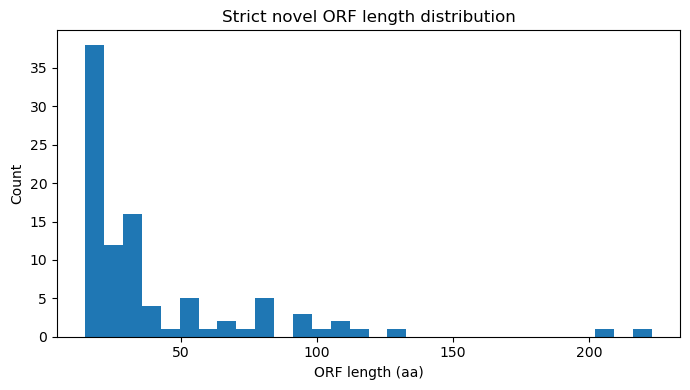

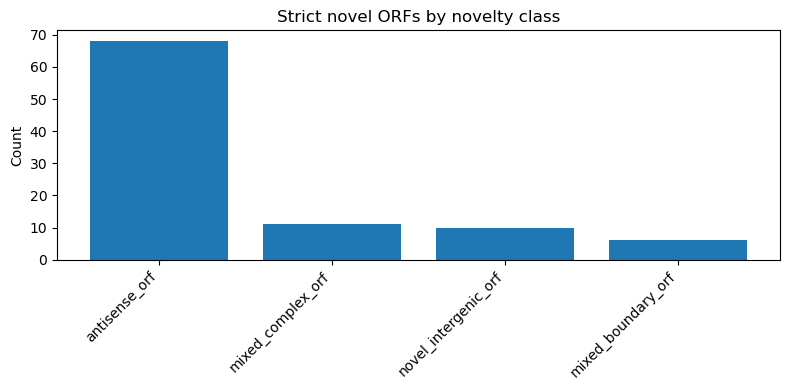

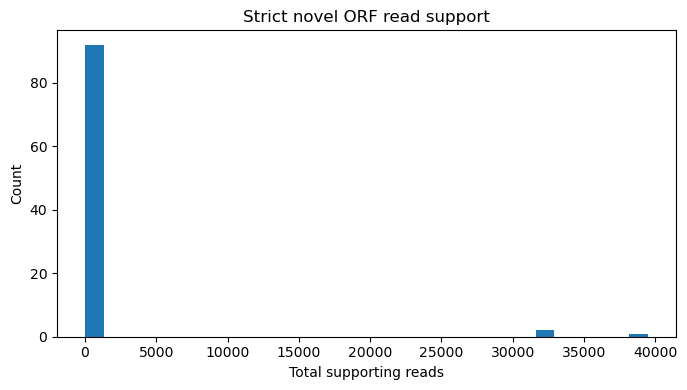

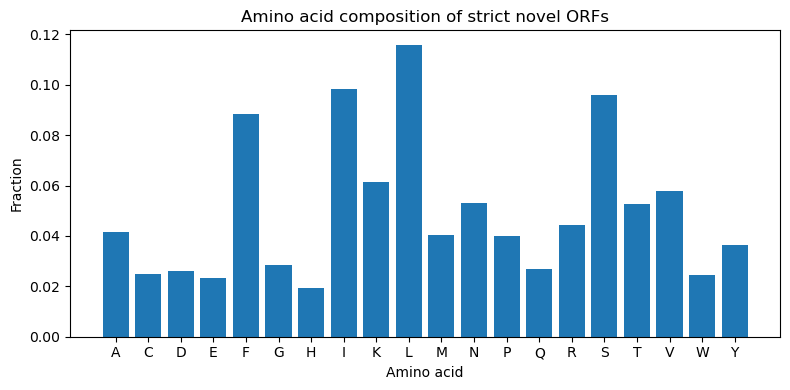

In [52]:
# ============================================================
# Statistics for novel_orfs_strict.fasta
# Parses FASTA headers written by the previous pipeline:
# >NR_ORF_00001|aa=35|term=complete_stop|score=9.0|tier=high|reads=27|novelty=novel_intergenic_orf|isoforms=ISO_...
# ============================================================

from __future__ import annotations
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STRICT_FASTA = OUT_FOLDER + "/novel_orfs_strict.fasta"   # or set full path manually
OUT_STATS_XLSX = OUT_FOLDER + "/novel_orfs_strict_stats.xlsx"
OUT_STATS_TSV  = OUT_FOLDER + "/novel_orfs_strict_stats.tsv"


# ----------------------------
# FASTA parser
# ----------------------------
def read_fasta(path: str):
    header = None
    seq_chunks = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq_chunks)
                header = line[1:]
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            yield header, "".join(seq_chunks)


def parse_header(header: str) -> dict:
    """
    Expected format:
    NR_ORF_00001|aa=35|term=complete_stop|score=9.0|tier=high|reads=27|novelty=novel_intergenic_orf|isoforms=ISO_...
    """
    parts = header.split("|")
    rec = {"nr_orf_id": parts[0]}
    for p in parts[1:]:
        if "=" in p:
            k, v = p.split("=", 1)
            rec[k] = v
    return rec


# ----------------------------
# Load FASTA
# ----------------------------
rows = []
for header, seq in read_fasta(STRICT_FASTA):
    rec = parse_header(header)
    rec["aa_seq"] = seq
    rec["aa_len_from_seq"] = len(seq)
    rows.append(rec)

strict_df = pd.DataFrame(rows)
if strict_df.empty:
    raise ValueError(f"No entries found in {STRICT_FASTA}")

# numeric conversion
for c in ["aa", "score", "reads"]:
    if c in strict_df.columns:
        strict_df[c] = pd.to_numeric(strict_df[c], errors="coerce")

# if aa field missing or inconsistent, use sequence length
if "aa" not in strict_df.columns:
    strict_df["aa"] = strict_df["aa_len_from_seq"]
strict_df["aa_len_match"] = strict_df["aa"] == strict_df["aa_len_from_seq"]

# derived metrics
strict_df["n_isoforms_support"] = strict_df["isoforms"].fillna("").apply(
    lambda x: 0 if x == "" else len([s for s in x.split(",") if s])
)

strict_df["is_intergenic"] = strict_df["novelty"].fillna("").str.contains("intergenic")
strict_df["is_antisense"] = strict_df["novelty"].fillna("").str.contains("antisense")
strict_df["is_boundary"] = strict_df["novelty"].fillna("").str.contains("boundary")
strict_df["is_complex"] = strict_df["novelty"].fillna("").str.contains("complex")


# ----------------------------
# Summary tables
# ----------------------------
overall_summary = pd.DataFrame([{
    "n_orfs": len(strict_df),
    "median_aa_len": strict_df["aa"].median(),
    "mean_aa_len": strict_df["aa"].mean(),
    "min_aa_len": strict_df["aa"].min(),
    "max_aa_len": strict_df["aa"].max(),
    "median_score": strict_df["score"].median() if "score" in strict_df.columns else np.nan,
    "mean_score": strict_df["score"].mean() if "score" in strict_df.columns else np.nan,
    "median_reads": strict_df["reads"].median() if "reads" in strict_df.columns else np.nan,
    "mean_reads": strict_df["reads"].mean() if "reads" in strict_df.columns else np.nan,
    "median_supporting_isoforms": strict_df["n_isoforms_support"].median(),
    "mean_supporting_isoforms": strict_df["n_isoforms_support"].mean(),
    "all_aa_len_match_header": bool(strict_df["aa_len_match"].all()),
}])

tier_summary = (
    strict_df.groupby("tier", dropna=False)
    .agg(
        n_orfs=("nr_orf_id", "size"),
        median_aa_len=("aa", "median"),
        mean_aa_len=("aa", "mean"),
        median_score=("score", "median"),
        mean_score=("score", "mean"),
        median_reads=("reads", "median"),
        mean_reads=("reads", "mean"),
        median_supporting_isoforms=("n_isoforms_support", "median"),
    )
    .reset_index()
    .sort_values("n_orfs", ascending=False)
)

novelty_summary = (
    strict_df.groupby("novelty", dropna=False)
    .agg(
        n_orfs=("nr_orf_id", "size"),
        median_aa_len=("aa", "median"),
        mean_aa_len=("aa", "mean"),
        median_score=("score", "median"),
        mean_score=("score", "mean"),
        median_reads=("reads", "median"),
        mean_reads=("reads", "mean"),
        median_supporting_isoforms=("n_isoforms_support", "median"),
    )
    .reset_index()
    .sort_values("n_orfs", ascending=False)
)

length_bins = pd.cut(
    strict_df["aa"],
    bins=[0, 15, 24, 40, 60, 100, np.inf],
    labels=["<=15", "16-24", "25-40", "41-60", "61-100", ">100"],
    right=True
)
length_summary = (
    length_bins.value_counts(dropna=False)
    .rename_axis("aa_len_bin")
    .reset_index(name="n_orfs")
)

# amino acid composition across all strict ORFs
aa_counts = {}
for seq in strict_df["aa_seq"]:
    for aa in seq:
        aa_counts[aa] = aa_counts.get(aa, 0) + 1

aa_comp = (
    pd.DataFrame({
        "aa": list(aa_counts.keys()),
        "count": list(aa_counts.values())
    })
    .sort_values("aa")
    .reset_index(drop=True)
)
aa_comp["fraction"] = aa_comp["count"] / aa_comp["count"].sum()

# top supported ORFs
top_by_score = strict_df.sort_values(
    ["score", "reads", "aa"], ascending=[False, False, False]
).head(50).copy()

top_by_reads = strict_df.sort_values(
    ["reads", "score", "aa"], ascending=[False, False, False]
).head(50).copy()


# ----------------------------
# Save tables
# ----------------------------
strict_df.to_csv(OUT_STATS_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_STATS_XLSX, engine="openpyxl") as writer:
    strict_df.to_excel(writer, sheet_name="strict_orfs", index=False)
    overall_summary.to_excel(writer, sheet_name="overall_summary", index=False)
    tier_summary.to_excel(writer, sheet_name="tier_summary", index=False)
    novelty_summary.to_excel(writer, sheet_name="novelty_summary", index=False)
    length_summary.to_excel(writer, sheet_name="length_summary", index=False)
    aa_comp.to_excel(writer, sheet_name="aa_composition", index=False)
    top_by_score.to_excel(writer, sheet_name="top_by_score", index=False)
    top_by_reads.to_excel(writer, sheet_name="top_by_reads", index=False)

print(f"✅ wrote {OUT_STATS_TSV}")
print(f"✅ wrote {OUT_STATS_XLSX}")

display(overall_summary)
display(novelty_summary)
display(length_summary)


# ----------------------------
# Plots
# ----------------------------
# 1) ORF length histogram
plt.figure(figsize=(7, 4))
plt.hist(strict_df["aa"].dropna(), bins=30)
plt.xlabel("ORF length (aa)")
plt.ylabel("Count")
plt.title("Strict novel ORF length distribution")
plt.tight_layout()
plt.savefig(OUT_FOLDER + "/strict_orf_length_distribution.png", dpi=300)
plt.show()

# 2) Novelty class barplot
novelty_counts = strict_df["novelty"].value_counts(dropna=False)
plt.figure(figsize=(8, 4))
plt.bar(novelty_counts.index.astype(str), novelty_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Strict novel ORFs by novelty class")
plt.tight_layout()
plt.savefig(OUT_FOLDER + "/strict_orf_novelty_class_distribution.png", dpi=300)
plt.show()

# 3) Reads distribution
if "reads" in strict_df.columns:
    plt.figure(figsize=(7, 4))
    plt.hist(strict_df["reads"].dropna(), bins=30)
    plt.xlabel("Total supporting reads")
    plt.ylabel("Count")
    plt.title("Strict novel ORF read support")
    plt.tight_layout()
    plt.show()

# 4) Amino acid composition
plt.figure(figsize=(8, 4))
plt.bar(aa_comp["aa"], aa_comp["fraction"])
plt.xlabel("Amino acid")
plt.ylabel("Fraction")
plt.title("Amino acid composition of strict novel ORFs")
plt.tight_layout()
plt.savefig(OUT_FOLDER + "/strict_orf_aa_composition.png", dpi=300)
plt.show()

## *In silico* trypsin digestion to Find MS Detectable ORF 

Loaded novel ORFs from FASTA: n=95
Loaded canonical proteins: n=828
Unique canonical tryptic peptide sequences: 61097
Novel ORF peptide rows (including duplicates across ORFs): 873
Unique novel tryptic peptide sequences: 735
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orf_tryptic_peptides.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orf_tryptic_summary.tsv
✅ wrote /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orf_tryptic_analysis.xlsx


,n_strict_orfs,n_strong_ms_candidates,n_medium_ms_candidates,n_weak_ms_candidates,n_not_trypsin_tractable,median_detectable_peptides_per_orf,median_unique_vs_canonical_detectable_per_orf,median_globally_unique_detectable_per_orf
0,95,94,0,0,1,4.0,4.0,3.0


,ms_priority,n_orfs,median_aa_len,median_reads,median_score,median_detectable_peptides,median_unique_vs_canonical,median_globally_unique
0,not_trypsin_tractable,1,26.0,10.0,14.0,0.0,0.0,0.0
1,strong_ms_candidate,94,27.5,42.0,14.0,4.0,4.0,3.0


,novel_orf_id,aa_len,term,score,tier,reads,novelty,isoforms,n_total_tryptic_peptides,n_unique_peptide_sequences,n_detectable_peptides,n_detectable_unique_sequences,n_unique_vs_canonical_detectable,n_globally_unique_novel_detectable,n_shared_with_canonical_detectable,example_unique_vs_canonical_peptides,example_globally_unique_peptides,n_supporting_isoforms,ms_priority
0,NR_ORF_01692,205,complete_stop,15.0,high,42,antisense_orf,ISO_036192,45,44,30,30,30,30,0,"GTSPLASGLPSSATIQCRSSLSLWR,RHCCQALMCPASDHAVAFGC...",HCCQALMCPASDHAVAFGCTTRTVSQSCPALSGCGSSGSSINCLPC...,1,strong_ms_candidate
1,NR_ORF_00078,130,complete_stop,15.0,high,42,antisense_orf,ISO_036192,37,36,25,25,25,17,0,"HTEVFRQTPLLPGADVPGFWPCGR,LPTLITQLDAKIHFAGGQMR,...","LPTLITQLDAKIHFAGGQMR,FTYANVVIQRCTGELIAQR,AWLAV...",1,strong_ms_candidate
2,NR_ORF_00306,113,complete_stop,15.0,high,40,antisense_orf,"ISO_079589,ISO_079599,ISO_079609",23,23,16,16,16,16,0,"SWAPFKVIWCPYSWAPTNFK,IGSLPLFPRSWAPFK,VIWCPYSWA...",SSLVNPKYLPFSSLYCITPFSSITFLMWGPSNHWAAYGTFSNNSSI...,3,strong_ms_candidate
3,NR_ORF_00339,83,complete_stop,15.0,high,25,antisense_orf,"ISO_004686,ISO_004689",27,26,15,15,15,15,0,"MFLGCNSNWGFIKNTPLVLNSR,SCFLAFLKLYWLMLITFK,LFKS...","MFLGCNSNWGFIKNTPLVLNSR,SCFLAFLKLYWLMLITFK,LFKS...",2,strong_ms_candidate
4,NR_ORF_00010,80,complete_stop,13.0,high,39509,mixed_boundary_orf,"ISO_001746,ISO_001757,ISO_001769,ISO_001774,IS...",23,21,13,13,13,13,0,"SAAASGISSLKGGNTVIHR,IIIILHNYTDFIAALGR,LLEPVSIG...","IIIILHNYTDFIAALGRSAAASGISSLK,SLPLPVGLVSKIIIILH...",149,strong_ms_candidate
5,NR_ORF_00554,78,complete_stop,15.0,high,31954,antisense_orf,"ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",27,25,12,12,12,12,0,"MIILASQTINVEGNSASLCKAFK,MIILASQTINVEGNSASLCK,E...","MIILASQTINVEGNSASLCKAFK,MIILASQTINVEGNSASLCK,E...",24,strong_ms_candidate
6,NR_ORF_02043,112,complete_stop,14.0,high,22,antisense_orf,ISO_041365,17,17,12,12,12,12,0,"MYSSTAAINSLIAPVHFESPFNAPK,SLISISTRSIISSSSTISHL...","MYSSTAAINSLIAPVHFESPFNAPKAEPLITGAPSPSK,MCSLVCG...",1,strong_ms_candidate
7,NR_ORF_01911,54,complete_stop,13.0,high,30,mixed_complex_orf,"ISO_030150,ISO_030156",19,19,10,10,10,10,0,"SWYFMPPFKIFYNFQILFSLR,IFYNFQILFSLRYSTK,MVLLLKS...","SWYFMPPFKIFYNFQILFSLR,IFYNFQILFSLRYSTK,MVLLLKS...",2,strong_ms_candidate
8,NR_ORF_00506,51,complete_stop,15.0,high,22,antisense_orf,ISO_033496,15,15,10,10,10,10,0,"MIAENPITNNERFFK,CDSKTYLTMFHTK,KYANIWTPAFVIG,MI...","MIAENPITNNERFFK,CDSKTYLTMFHTK,KYANIWTPAFVIG,MI...",1,strong_ms_candidate
9,NR_ORF_01600,52,complete_stop,16.0,high,42,antisense_orf,ISO_036192,17,16,9,9,9,9,0,"VAVFIIFNQRLIHPVPDEAAL,ITAVSRPRVAVFIIFNQR,AVGKD...","VAVFIIFNQRLIHPVPDEAAL,ITAVSRPRVAVFIIFNQR,AVGKD...",1,strong_ms_candidate


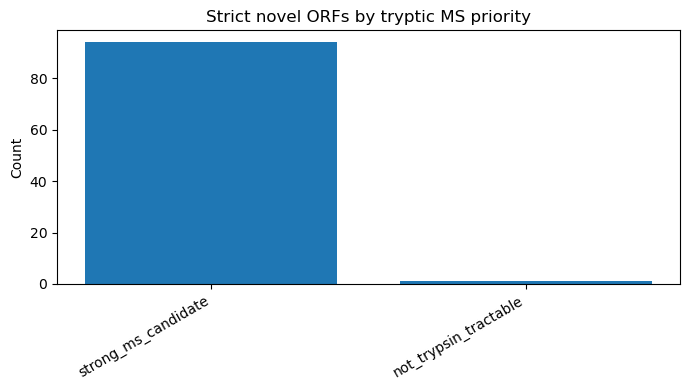

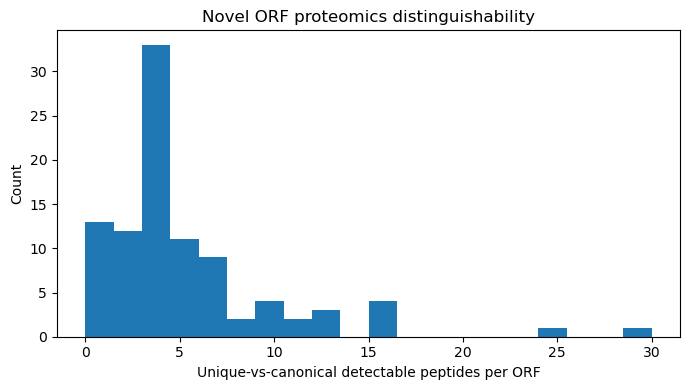

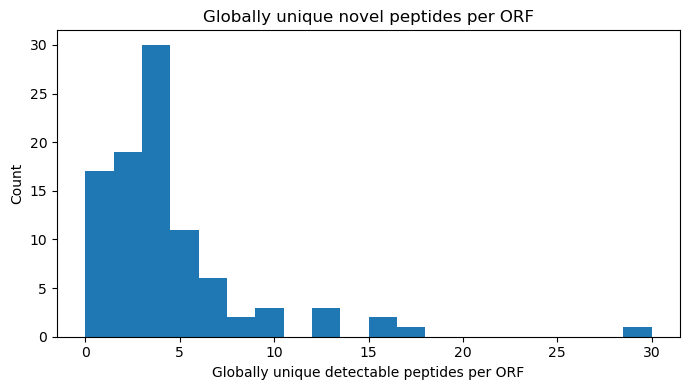

ms_priority,not_trypsin_tractable,strong_ms_candidate
novelty,,
antisense_orf,1,67
mixed_boundary_orf,0,6
mixed_complex_orf,0,11
novel_intergenic_orf,0,10


In [48]:
# ============================================================
# In silico trypsin digestion for novel_orfs_strict.fasta
# Compare against canonical Syn1 proteome FASTA
#
# FIXED VERSION:
#   - counts peptide SEQUENCES, not duplicated rows
#   - guarantees:
#         Globally_unique <= Unique_vs_canonical <= Detectable
#
# Outputs:
#   1. peptide-level table for novel ORFs
#   2. ORF-level proteomics feasibility summary
#   3. Excel workbook with ranked candidate lists
# ============================================================

from __future__ import annotations
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Inputs
# ----------------------------
STRICT_FASTA = OUT_FOLDER + "/novel_orfs_strict.fasta"
CANONICAL_FASTA = MOTHER_FOLDER + "/syn1_genome/syn1_proteins.faa"

OUT_DIGEST_FOLDER = OUT_FOLDER + "/trypsin_digest"
Path(OUT_DIGEST_FOLDER).mkdir(parents=True, exist_ok=True)

OUT_NOVEL_PEPTIDES_TSV = OUT_DIGEST_FOLDER + "/novel_orf_tryptic_peptides.tsv"
OUT_ORF_SUMMARY_TSV    = OUT_DIGEST_FOLDER + "/novel_orf_tryptic_summary.tsv"
OUT_DIGEST_XLSX        = OUT_DIGEST_FOLDER + "/novel_orf_tryptic_analysis.xlsx"

# ----------------------------
# Digestion settings
# ----------------------------
MAX_MISSED_CLEAVAGES = 1
MIN_PEPTIDE_LEN = 7
MAX_PEPTIDE_LEN = 25

EXCLUDE_PEPTIDES_WITH_X = True
EXCLUDE_EMPTY = True


# ----------------------------
# FASTA helpers
# ----------------------------
def read_fasta(path: str):
    header = None
    seq_chunks = []
    with open(path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq_chunks)
                header = line[1:]
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            yield header, "".join(seq_chunks)

def parse_novel_header(header: str) -> dict:
    parts = header.split("|")
    rec = {"protein_id": parts[0], "header": header}
    for p in parts[1:]:
        if "=" in p:
            k, v = p.split("=", 1)
            rec[k] = v
    return rec

def parse_canonical_header(header: str) -> dict:
    protein_id = header.split()[0]
    return {"protein_id": protein_id, "header": header}


# ----------------------------
# Trypsin digestion
# ----------------------------
def trypsin_cleavage_sites(seq: str) -> list[int]:
    seq = seq.upper()
    cuts = [0]
    for i in range(len(seq) - 1):
        aa = seq[i]
        nxt = seq[i + 1]
        if aa in {"K", "R"} and nxt != "P":
            cuts.append(i + 1)
    cuts.append(len(seq))
    return cuts

def digest_trypsin(seq: str, max_missed_cleavages: int = 1) -> list[dict]:
    seq = seq.upper()
    cuts = trypsin_cleavage_sites(seq)

    peptides = []
    for i in range(len(cuts) - 1):
        for mc in range(max_missed_cleavages + 1):
            j = i + mc + 1
            if j >= len(cuts):
                continue
            start = cuts[i]
            end = cuts[j]
            pep = seq[start:end]
            if EXCLUDE_EMPTY and len(pep) == 0:
                continue
            if EXCLUDE_PEPTIDES_WITH_X and ("X" in pep):
                continue
            peptides.append({
                "peptide_seq": pep,
                "pep_start0": int(start),
                "pep_end0": int(end),
                "missed_cleavages": int(mc),
                "pep_len": int(len(pep)),
            })
    return peptides


# ----------------------------
# Load novel ORFs
# ----------------------------
novel_rows = []
for header, seq in read_fasta(STRICT_FASTA):
    meta = parse_novel_header(header)
    meta["aa_seq"] = seq
    meta["aa_len_from_seq"] = len(seq)
    novel_rows.append(meta)

novel_df = pd.DataFrame(novel_rows)
if novel_df.empty:
    raise ValueError(f"No entries found in {STRICT_FASTA}")

for c in ["aa", "score", "reads"]:
    if c in novel_df.columns:
        novel_df[c] = pd.to_numeric(novel_df[c], errors="coerce")

if "aa" not in novel_df.columns:
    novel_df["aa"] = novel_df["aa_len_from_seq"]

print(f"Loaded novel ORFs from FASTA: n={len(novel_df)}")


# ----------------------------
# Load canonical proteome
# ----------------------------
canonical_rows = []
for header, seq in read_fasta(CANONICAL_FASTA):
    meta = parse_canonical_header(header)
    meta["aa_seq"] = seq
    meta["aa_len"] = len(seq)
    canonical_rows.append(meta)

canonical_df = pd.DataFrame(canonical_rows)
if canonical_df.empty:
    raise ValueError(f"No entries found in {CANONICAL_FASTA}")

print(f"Loaded canonical proteins: n={len(canonical_df)}")


# ----------------------------
# Digest canonical proteome
# ----------------------------
canonical_peptide_to_proteins = defaultdict(set)

for _, row in canonical_df.iterrows():
    pid = row["protein_id"]
    seq = row["aa_seq"]
    peps = digest_trypsin(seq, max_missed_cleavages=MAX_MISSED_CLEAVAGES)
    for p in peps:
        pep = p["peptide_seq"]
        canonical_peptide_to_proteins[pep].add(pid)

print(f"Unique canonical tryptic peptide sequences: {len(canonical_peptide_to_proteins)}")


# ----------------------------
# Digest novel ORFs
# ----------------------------
novel_peptide_rows = []
novel_peptide_to_orfs = defaultdict(set)

for _, row in novel_df.iterrows():
    pid = row["protein_id"]
    seq = row["aa_seq"]
    peps = digest_trypsin(seq, max_missed_cleavages=MAX_MISSED_CLEAVAGES)

    for p in peps:
        pep = p["peptide_seq"]
        pep_len = p["pep_len"]
        detectable = (MIN_PEPTIDE_LEN <= pep_len <= MAX_PEPTIDE_LEN)

        novel_peptide_rows.append({
            "novel_orf_id": pid,
            "aa_len": row.get("aa", np.nan),
            "term": row.get("term", ""),
            "score": row.get("score", np.nan),
            "tier": row.get("tier", ""),
            "reads": row.get("reads", np.nan),
            "novelty": row.get("novelty", ""),
            "isoforms": row.get("isoforms", ""),
            "peptide_seq": pep,
            "pep_start0": p["pep_start0"],
            "pep_end0": p["pep_end0"],
            "pep_len": pep_len,
            "missed_cleavages": p["missed_cleavages"],
            "detectable_len": bool(detectable),
        })
        novel_peptide_to_orfs[pep].add(pid)

novel_peptides_df = pd.DataFrame(novel_peptide_rows)
if novel_peptides_df.empty:
    raise ValueError("No tryptic peptides generated for novel ORFs.")

print(f"Novel ORF peptide rows (including duplicates across ORFs): {len(novel_peptides_df)}")
print(f"Unique novel tryptic peptide sequences: {novel_peptides_df['peptide_seq'].nunique()}")


# ----------------------------
# Annotate peptide uniqueness
# ----------------------------
def peptide_classification(pep: str, detectable: bool) -> dict:
    in_canonical = pep in canonical_peptide_to_proteins
    novel_orf_count = len(novel_peptide_to_orfs[pep])

    unique_vs_canonical = (not in_canonical)
    globally_unique_novel = (not in_canonical) and (novel_orf_count == 1)

    return {
        "in_canonical": bool(in_canonical),
        "n_canonical_proteins": int(len(canonical_peptide_to_proteins.get(pep, set()))),
        "n_novel_orfs_sharing_peptide": int(novel_orf_count),
        "unique_vs_canonical": bool(unique_vs_canonical),
        "globally_unique_novel": bool(globally_unique_novel),
        "usable_for_ms": bool(detectable and unique_vs_canonical),
        "best_ms_specificity": (
            "globally_unique_novel" if (detectable and globally_unique_novel) else
            "unique_vs_canonical" if (detectable and unique_vs_canonical) else
            "shared_with_canonical" if detectable else
            "not_detectable_len"
        )
    }

annot = []
for _, r in novel_peptides_df.iterrows():
    d = peptide_classification(r["peptide_seq"], bool(r["detectable_len"]))
    rec = r.to_dict()
    rec.update(d)
    annot.append(rec)

novel_peptides_df = pd.DataFrame(annot)


# ----------------------------
# FIX: ORF-level summary must count UNIQUE PEPTIDE SEQUENCES,
# not duplicated rows
# ----------------------------
def unique_peptide_count(subdf: pd.DataFrame, mask_col: str | None = None) -> int:
    if mask_col is None:
        return int(subdf["peptide_seq"].drop_duplicates().shape[0])
    return int(subdf.loc[subdf[mask_col], "peptide_seq"].drop_duplicates().shape[0])

def top_unique_peptides(subdf: pd.DataFrame, col: str, n: int = 5) -> str:
    x = (
        subdf[subdf[col]]
        .sort_values(["pep_len", "missed_cleavages", "peptide_seq"], ascending=[False, True, True])
        ["peptide_seq"]
        .drop_duplicates()
        .head(n)
        .tolist()
    )
    return ",".join(x)

def summarize_orf(group: pd.DataFrame) -> pd.Series:
    detectable = group[group["detectable_len"]].copy()
    detectable_unique_vs_canonical = detectable[detectable["unique_vs_canonical"]].copy()
    detectable_globally_unique = detectable[detectable["globally_unique_novel"]].copy()
    detectable_shared_with_canonical = detectable[~detectable["unique_vs_canonical"]].copy()

    return pd.Series({
        "aa_len": group["aa_len"].iloc[0],
        "term": group["term"].iloc[0],
        "score": group["score"].iloc[0],
        "tier": group["tier"].iloc[0],
        "reads": group["reads"].iloc[0],
        "novelty": group["novelty"].iloc[0],
        "isoforms": group["isoforms"].iloc[0],

        "n_total_tryptic_peptides": int(len(group)),
        "n_unique_peptide_sequences": unique_peptide_count(group),

        "n_detectable_peptides": unique_peptide_count(detectable),
        "n_detectable_unique_sequences": unique_peptide_count(detectable),

        "n_unique_vs_canonical_detectable": unique_peptide_count(detectable_unique_vs_canonical),
        "n_globally_unique_novel_detectable": unique_peptide_count(detectable_globally_unique),

        "n_shared_with_canonical_detectable": unique_peptide_count(detectable_shared_with_canonical),
    })

orf_summary = (
    novel_peptides_df.groupby("novel_orf_id", dropna=False)
    .apply(summarize_orf, include_groups=False)
    .reset_index()
)

# Add best peptide examples
best_unique_vs_canonical = (
    novel_peptides_df.groupby("novel_orf_id", dropna=False)
    .apply(lambda g: top_unique_peptides(g, "usable_for_ms", n=5), include_groups=False)
    .reset_index(name="example_unique_vs_canonical_peptides")
)

best_globally_unique = (
    novel_peptides_df.groupby("novel_orf_id", dropna=False)
    .apply(lambda g: top_unique_peptides(g, "globally_unique_novel", n=5), include_groups=False)
    .reset_index(name="example_globally_unique_peptides")
)

orf_summary = orf_summary.merge(best_unique_vs_canonical, on="novel_orf_id", how="left")
orf_summary = orf_summary.merge(best_globally_unique, on="novel_orf_id", how="left")

# supporting isoform count
orf_summary["n_supporting_isoforms"] = orf_summary["isoforms"].fillna("").apply(
    lambda x: 0 if x == "" else len([s for s in x.split(",") if s])
)

# sanity checks
assert (orf_summary["n_globally_unique_novel_detectable"] <= orf_summary["n_unique_vs_canonical_detectable"]).all()
assert (orf_summary["n_unique_vs_canonical_detectable"] <= orf_summary["n_detectable_peptides"]).all()


# ----------------------------
# Priority classes
# ----------------------------
def classify_ms_priority(row) -> str:
    guniq = int(row["n_globally_unique_novel_detectable"])
    uniq = int(row["n_unique_vs_canonical_detectable"])
    det = int(row["n_detectable_peptides"])

    if guniq >= 1 or uniq >= 2:
        return "strong_ms_candidate"
    elif uniq >= 1:
        return "medium_ms_candidate"
    elif det >= 1:
        return "weak_ms_candidate"
    else:
        return "not_trypsin_tractable"

orf_summary["ms_priority"] = orf_summary.apply(classify_ms_priority, axis=1)

priority_order = {
    "strong_ms_candidate": 0,
    "medium_ms_candidate": 1,
    "weak_ms_candidate": 2,
    "not_trypsin_tractable": 3,
}
orf_summary["ms_priority_rank"] = orf_summary["ms_priority"].map(priority_order)

orf_summary = orf_summary.sort_values(
    ["ms_priority_rank", "n_globally_unique_novel_detectable", "n_unique_vs_canonical_detectable", "reads", "score", "aa_len"],
    ascending=[True, False, False, False, False, False]
).drop(columns="ms_priority_rank").reset_index(drop=True)


# ----------------------------
# Summary tables
# ----------------------------
overall_summary = pd.DataFrame([{
    "n_strict_orfs": len(orf_summary),
    "n_strong_ms_candidates": int((orf_summary["ms_priority"] == "strong_ms_candidate").sum()),
    "n_medium_ms_candidates": int((orf_summary["ms_priority"] == "medium_ms_candidate").sum()),
    "n_weak_ms_candidates": int((orf_summary["ms_priority"] == "weak_ms_candidate").sum()),
    "n_not_trypsin_tractable": int((orf_summary["ms_priority"] == "not_trypsin_tractable").sum()),
    "median_detectable_peptides_per_orf": orf_summary["n_detectable_peptides"].median(),
    "median_unique_vs_canonical_detectable_per_orf": orf_summary["n_unique_vs_canonical_detectable"].median(),
    "median_globally_unique_detectable_per_orf": orf_summary["n_globally_unique_novel_detectable"].median(),
}])

priority_summary = (
    orf_summary.groupby("ms_priority", dropna=False)
    .agg(
        n_orfs=("novel_orf_id", "size"),
        median_aa_len=("aa_len", "median"),
        median_reads=("reads", "median"),
        median_score=("score", "median"),
        median_detectable_peptides=("n_detectable_peptides", "median"),
        median_unique_vs_canonical=("n_unique_vs_canonical_detectable", "median"),
        median_globally_unique=("n_globally_unique_novel_detectable", "median"),
    )
    .reset_index()
)

novelty_priority_summary = (
    orf_summary.groupby(["novelty", "ms_priority"], dropna=False)
    .agg(
        n_orfs=("novel_orf_id", "size"),
        median_reads=("reads", "median"),
        median_detectable_peptides=("n_detectable_peptides", "median"),
        median_unique_vs_canonical=("n_unique_vs_canonical_detectable", "median"),
    )
    .reset_index()
    .sort_values(["novelty", "n_orfs"], ascending=[True, False])
)

top_strong = orf_summary[orf_summary["ms_priority"] == "strong_ms_candidate"].head(100).copy()


# ----------------------------
# Write outputs
# ----------------------------
novel_peptides_df.to_csv(OUT_NOVEL_PEPTIDES_TSV, sep="\t", index=False)
orf_summary.to_csv(OUT_ORF_SUMMARY_TSV, sep="\t", index=False)

with pd.ExcelWriter(OUT_DIGEST_XLSX, engine="openpyxl") as writer:
    overall_summary.to_excel(writer, sheet_name="overall_summary", index=False)
    priority_summary.to_excel(writer, sheet_name="priority_summary", index=False)
    novelty_priority_summary.to_excel(writer, sheet_name="novelty_priority", index=False)
    orf_summary.to_excel(writer, sheet_name="orf_summary", index=False)
    top_strong.to_excel(writer, sheet_name="top_strong_candidates", index=False)
    novel_peptides_df.to_excel(writer, sheet_name="novel_peptides", index=False)

print(f"✅ wrote {OUT_NOVEL_PEPTIDES_TSV}")
print(f"✅ wrote {OUT_ORF_SUMMARY_TSV}")
print(f"✅ wrote {OUT_DIGEST_XLSX}")

display(overall_summary)
display(priority_summary)
display(orf_summary.head(20))


# ----------------------------
# Plots
# ----------------------------
priority_counts = orf_summary["ms_priority"].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(priority_counts.index.astype(str), priority_counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("Strict novel ORFs by tryptic MS priority")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(orf_summary["n_unique_vs_canonical_detectable"].dropna(), bins=20)
plt.xlabel("Unique-vs-canonical detectable peptides per ORF")
plt.ylabel("Count")
plt.title("Novel ORF proteomics distinguishability")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(orf_summary["n_globally_unique_novel_detectable"].dropna(), bins=20)
plt.xlabel("Globally unique detectable peptides per ORF")
plt.ylabel("Count")
plt.title("Globally unique novel peptides per ORF")
plt.tight_layout()
plt.show()

novelty_pivot = (
    orf_summary.pivot_table(index="novelty", columns="ms_priority", values="novel_orf_id", aggfunc="count", fill_value=0)
)
display(novelty_pivot)

### Export FASTA of uniquely identifiable ORFs

In [49]:
# ------------------------------------------------
# ORFs uniquely identifiable by proteomics
# ------------------------------------------------

ms_identifiable_orfs = orf_summary[
    orf_summary["n_unique_vs_canonical_detectable"] >= 1
].copy()

print("ORFs uniquely identifiable by MS:", len(ms_identifiable_orfs))

# stronger set (optional)
ms_strong_orfs = orf_summary[
    orf_summary["n_unique_vs_canonical_detectable"] >= 2
].copy()

print("ORFs with >=2 unique peptides:", len(ms_strong_orfs))


# ------------------------------------------------
# Export final FASTA for proteomics
# ------------------------------------------------

identifiable_ids = set(ms_identifiable_orfs["novel_orf_id"])

final_fasta = OUT_DIGEST_FOLDER + "/novel_orfs_ms_identifiable.fasta"

with open(STRICT_FASTA) as fin, open(final_fasta,"w") as fout:

    write = False

    for line in fin:
        if line.startswith(">"):
            orf_id = line[1:].split("|")[0]
            write = orf_id in identifiable_ids

        if write:
            fout.write(line)

print("Final MS-identifiable ORFs FASTA:", final_fasta)

ORFs uniquely identifiable by MS: 94
ORFs with >=2 unique peptides: 82
Final MS-identifiable ORFs FASTA: /data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orfs_ms_identifiable.fasta


### Excel summary of final FASTA file

In [50]:
# ============================================================
# Build final ORF table for proteomics collaborator
# ============================================================

FINAL_TABLE_TSV  = OUT_DIGEST_FOLDER + "/novel_orf_final_table.tsv"
FINAL_TABLE_XLSX = OUT_DIGEST_FOLDER + "/novel_orf_final_table.xlsx"


# ------------------------------------------------------------
# Select MS-identifiable ORFs
# ------------------------------------------------------------

final_orfs = orf_summary[
    orf_summary["n_unique_vs_canonical_detectable"] >= 1
].copy()

print("Final ORFs retained:", len(final_orfs))


# ------------------------------------------------------------
# Add example peptides
# ------------------------------------------------------------

def get_example_peptides(orf_id, n=3):

    df = novel_peptides_df[
        (novel_peptides_df["novel_orf_id"] == orf_id) &
        (novel_peptides_df["usable_for_ms"])
    ].sort_values(
        ["pep_len","missed_cleavages"],
        ascending=[False,True]
    )

    peps = df["peptide_seq"].drop_duplicates().head(n).tolist()

    return ",".join(peps)


final_orfs["example_unique_peptides"] = final_orfs["novel_orf_id"].apply(get_example_peptides)


# ------------------------------------------------------------
# Load amino acid sequences
# ------------------------------------------------------------

from Bio import SeqIO

seq_map = {}

for rec in SeqIO.parse(STRICT_FASTA,"fasta"):
    pid = rec.id.split("|")[0]
    seq_map[pid] = str(rec.seq)

final_orfs["aa_sequence"] = final_orfs["novel_orf_id"].map(seq_map)


# ------------------------------------------------------------
# Build clean table
# ------------------------------------------------------------

final_table = final_orfs[[
    "novel_orf_id",
    "novelty",
    "aa_len",
    "reads",
	"isoforms",
	"n_supporting_isoforms",
    "score",
    "n_detectable_peptides",
    "n_unique_vs_canonical_detectable",
    "n_globally_unique_novel_detectable",
    "example_unique_peptides",
    "aa_sequence"
]].copy()


final_table = final_table.rename(columns={

    "novel_orf_id":"ORF_ID",
    "novelty":"Novelty_class",
    "aa_len":"Protein_length_aa",
    "reads":"Transcript_reads",
	"isoforms":"Supporting_isoform_ids",
	"n_supporting_isoforms":"Supporting_isoforms",
    "score":"Confidence_score",
    "n_detectable_peptides":"Detectable_tryptic_peptides",
    "n_unique_vs_canonical_detectable":"Unique_vs_canonical_peptides",
    "n_globally_unique_novel_detectable":"Globally_unique_peptides",
})


# ------------------------------------------------------------
# Sort most convincing first
# ------------------------------------------------------------

final_table = final_table.sort_values(
    ["Transcript_reads","Unique_vs_canonical_peptides","Protein_length_aa"],
    ascending=[False,False,False]
).reset_index(drop=True)


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

final_table.to_csv(FINAL_TABLE_TSV,sep="\t",index=False)

with pd.ExcelWriter(FINAL_TABLE_XLSX) as writer:

    final_table.to_excel(writer,sheet_name="novel_orfs",index=False)

    priority_summary.to_excel(writer,sheet_name="priority_summary",index=False)

    overall_summary.to_excel(writer,sheet_name="dataset_summary",index=False)


print("Final table written:")
print(FINAL_TABLE_TSV)
print(FINAL_TABLE_XLSX)


# ------------------------------------------------------------
# Quick preview
# ------------------------------------------------------------

display(final_table.head(20))

Final ORFs retained: 94
Final table written:
/data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orf_final_table.tsv
/data/enguang/CMEODE/TRSC/Transcriptomics/RNAseq_analysis/novel_orf_discovery/trypsin_digest/novel_orf_final_table.xlsx


,ORF_ID,Novelty_class,Protein_length_aa,Transcript_reads,Supporting_isoform_ids,Supporting_isoforms,Confidence_score,Detectable_tryptic_peptides,Unique_vs_canonical_peptides,Globally_unique_peptides,example_unique_peptides,aa_sequence
0,NR_ORF_00010,mixed_boundary_orf,80,39509,"ISO_001746,ISO_001757,ISO_001769,ISO_001774,IS...",149,13.0,13,13,13,"SAAASGISSLKGGNTVIHR,IIIILHNYTDFIAALGR,RLLEPVSI...",MAEYRRFPYGDWWRRLLEPVSIGGITAERRSLPLPVGLVSKIIIIL...
1,NR_ORF_00554,antisense_orf,78,31954,"ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",24,15.0,12,12,12,"MIILASQTINVEGNSASLCKAFK,MIILASQTINVEGNSASLCK,E...",MIILASQTINVEGNSASLCKAFKKMRDHLAREISYFLPLQTKFDNC...
2,NR_ORF_00351,mixed_complex_orf,32,31938,"ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",23,11.0,4,4,1,"TVIWPFYFYTVKSR,RTVIWPFYFYTVK,TVIWPFYFYTVK",MFLSLKTLYRKRTVIWPFYFYTVKSRLLCKTT
3,NR_ORF_01144,novel_intergenic_orf,20,994,"ISO_008214,ISO_008215,ISO_008217,ISO_008220,IS...",6,13.0,3,3,3,"MLSKTSYDISPPISLIK,TSYDISPPISLIKSLK,TSYDISPPISLIK",MLSKTSYDISPPISLIKSLK
4,NR_ORF_00567,novel_intergenic_orf,17,654,"ISO_017621,ISO_017622,ISO_017623,ISO_017627,IS...",7,13.0,2,2,2,"MIITYTTVLMNKLTR,MIITYTTVLMNK",MIITYTTVLMNKLTRIN
5,NR_ORF_00206,mixed_boundary_orf,30,557,"ISO_019872,ISO_019878,ISO_019879,ISO_019881,IS...",8,13.0,6,6,6,"MDTYFLLIIVLEKDVIIIIK,MDTYFLLIIVLEK,ELLYEKVVS",MDTYFLLIIVLEKDVIIIIKKELLYEKVVS
6,NR_ORF_01980,mixed_complex_orf,80,556,"ISO_035230,ISO_035233,ISO_035234,ISO_035237,IS...",31,13.0,16,16,1,"ELIINSQKATSQTSMLLFVFLYK,TAIAILNYQYFLKDIAFLNK,D...",MWMTTKYVRFWQRRQVLTCLKVKELIINSQKATSQTSMLLFVFLYK...
7,NR_ORF_01834,mixed_complex_orf,78,556,"ISO_035230,ISO_035233,ISO_035234,ISO_035237,IS...",31,13.0,16,16,1,"ELIINSQKATSQTSMLLFVFLYK,TAIAILNYQYFLKDIAFLNK,D...",MTTKYVRFWQRRQVLTCLKVKELIINSQKATSQTSMLLFVFLYKKR...
8,NR_ORF_02024,mixed_complex_orf,43,454,"ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",6,13.0,7,7,4,"MYLGHVKVLLGMFLSLK,VLLGMFLSLKTLYR,TVIWPFYFYTVKSR",MYLGHVKVLLGMFLSLKTLYRKRTVIWPFYFYTVKSRLLCKTT
9,NR_ORF_01169,mixed_complex_orf,16,454,"ISO_001117,ISO_001136,ISO_001147,ISO_001155,IS...",6,11.0,2,2,2,"MLWISSLFSVKCTWVM,MLWISSLFSVK",MLWISSLFSVKCTWVM


## Mass Spec